In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from pathlib import Path
import pandas as pd
import json
from src.config import CHECKPOINT_DIR, DEFAULT_TRAINING_PARAMS_V2, DEFAULT_TRAINING_PARAMS_V3, DEFAULT_TRAINING_PARAMS_V4, DEFAULT_STGCN_PARAMS_V1
from pathlib import Path
import matplotlib.pyplot as plt



In [2]:
# cnn_lstm
experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V3" / "grid_search_10"
experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V4" / "regularisation_search"

default_config = DEFAULT_TRAINING_PARAMS_V4

In [3]:
grid_search_results_path = experiment_root / "grid_search_results.csv"

df = pd.read_csv(grid_search_results_path)
df = df.sort_values("best_val_acc", ascending=False)
df.head(50)

,run_name,seed,num_frames,augment,batch_size,input_mode,learning_rate,cnn_learning_rate,min_lr,cnn_min_lr,...,dropout,cnn_cutoff,cnn_unfreeze_from,freeze_cnn_batchnorm,best_val_acc,final_train_acc,final_val_acc,final_train_loss,final_val_loss,epochs_ran
1,lr_5e-5,42,32,True,8,diff,0.00005,0.000001,0.00001,1.000000e-07,...,0.35,19,NaN,True,0.8650,0.916875,0.8500,0.343135,0.436140,24
2,lr_2e-4,42,32,True,8,diff,0.00020,0.000001,0.00001,1.000000e-07,...,0.35,19,NaN,True,0.8650,0.959375,0.8550,0.284179,0.468377,20
4,dropout_0.25,42,32,True,8,diff,0.00010,0.000001,0.00001,1.000000e-07,...,0.25,19,NaN,True,0.8650,0.943750,0.8475,0.302470,0.458064,21
12,ls_0.05,42,32,True,8,diff,0.00010,0.000001,0.00001,1.000000e-07,...,0.35,19,NaN,True,0.8650,0.961250,0.8600,0.214998,0.440512,27
8,wd_1e-5,42,32,True,8,diff,0.00010,0.000001,0.00001,1.000000e-07,...,0.35,19,NaN,True,0.8625,0.951875,0.8325,0.296398,0.476648,28
11,ls_0.0,42,32,True,8,diff,0.00010,0.000001,0.00001,1.000000e-07,...,0.35,19,NaN,True,0.8600,0.927500,0.8475,0.182409,0.408725,17
5,dropout_0.45,42,32,True,8,diff,0.00010,0.000001,0.00001,1.000000e-07,...,0.45,19,NaN,True,0.8575,0.930625,0.8425,0.328393,0.449389,17
3,lr_3e-4,42,32,True,8,diff,0.00030,0.000001,0.00001,1.000000e-07,...,0.35,19,NaN,True,0.8575,0.958750,0.8450,0.274058,0.496218,20
0,baseline,42,32,True,8,diff,0.00010,0.000001,0.00001,1.000000e-07,...,0.35,19,NaN,True,0.8575,0.928750,0.8500,0.321739,0.455225,17
9,wd_5e-5,42,32,True,8,diff,0.00010,0.000001,0.00001,1.000000e-07,...,0.35,19,NaN,True,0.8575,0.940000,0.8475,0.309100,0.457638,21


In [4]:
def make_title(run_name, config, default_config=DEFAULT_TRAINING_PARAMS_V3):
    title = [run_name]

    for param in config:
        if param in default_config and config[param] != default_config[param]:
            title.append(f"{param}={config[param]}")

    return " | ".join(title)

def get_results(results_path):

    checkpoint_path = results_path / "best_model.pt"
    history_path = results_path / "history.csv"
    summary_path = results_path / "summary.csv"
    config_path = results_path / "config.json"

    required_files = [
        checkpoint_path,
        history_path,
        summary_path,
        config_path,
    ]

    if not all(path.exists() for path in required_files):
        return None

    checkpoint = torch.load(
        checkpoint_path,
        map_location=torch.device("cpu")
    )

    history = pd.read_csv(history_path)
    summary = pd.read_csv(summary_path)

    with config_path.open("r", encoding="utf-8") as f:
        config = json.load(f)

    return checkpoint, history, summary, config

def plot_grid_search_results(experiment_root, default_config):

    run_dirs = sorted([d for d in experiment_root.iterdir() if d.is_dir()])
    
    for run_dir in run_dirs:

        results = get_results(run_dir)

        if results is None:
            print(f"Skipping incomplete run: {run_dir.name}")
            continue

        checkpoint, history, summary, config = results

        epochs = range(1, len(history["train_loss"]) + 1)

        title = make_title(run_dir.name, config, default_config=default_config)

        plt.figure(figsize=(12, 5))

        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, history["train_loss"], label="Train Loss")
        plt.plot(epochs, history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss")
        plt.legend()
        plt.grid(True)

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history["train_acc"], label="Train Acc")
        plt.plot(epochs, history["val_acc"], label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

        print(summary['best_val_acc'][0])
        print(config)

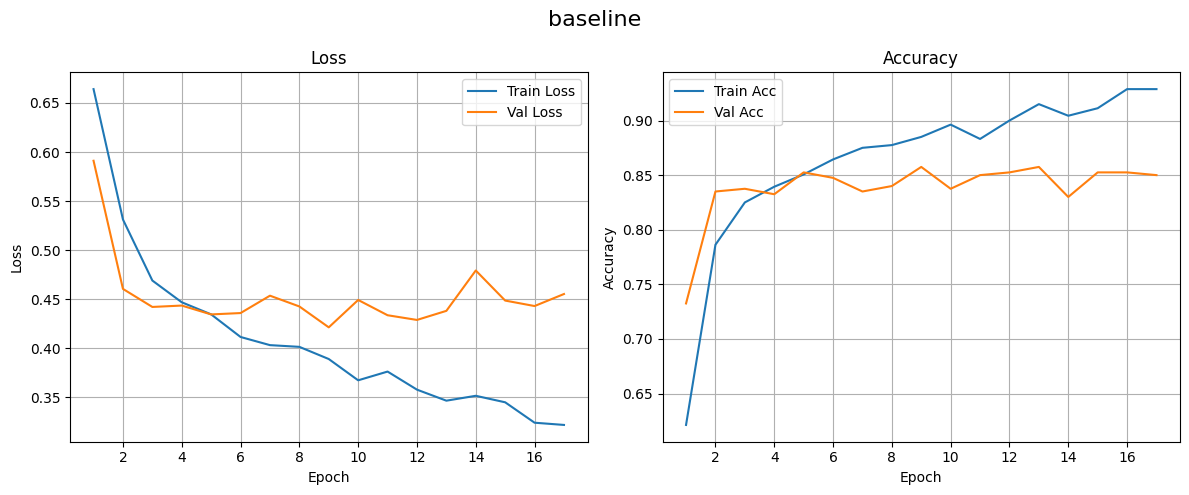

0.8575
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


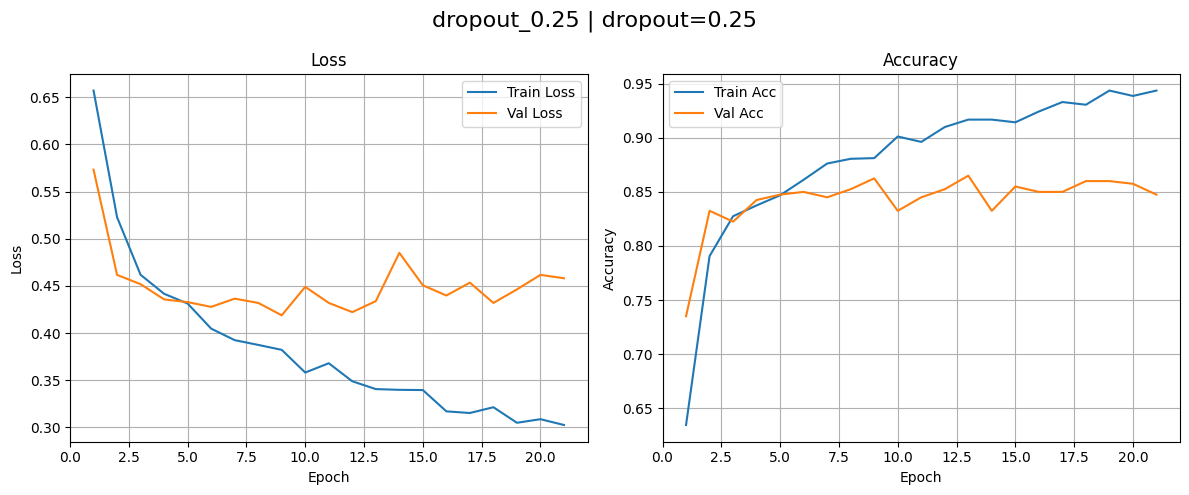

0.865
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.25, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


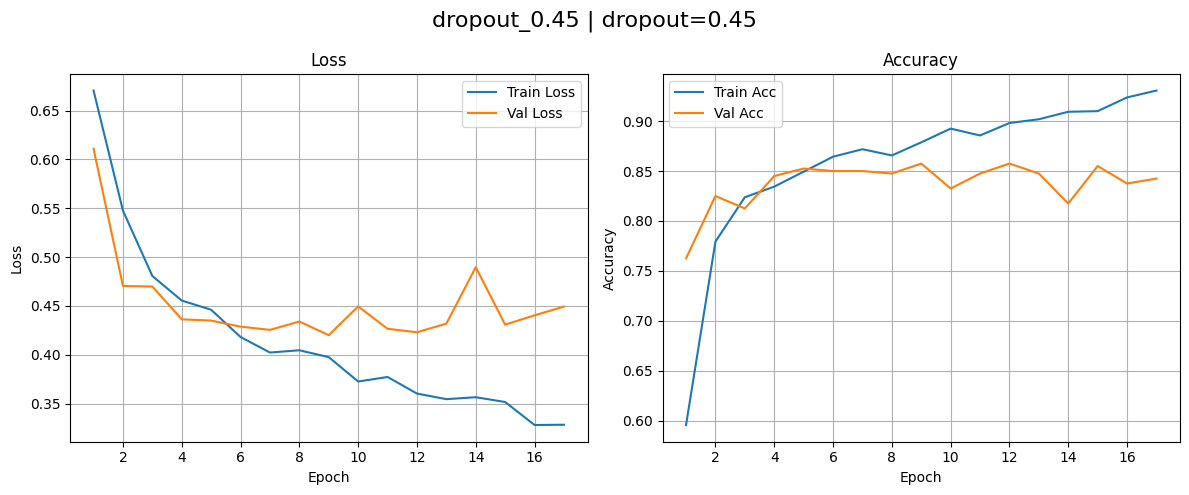

0.8575
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.45, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


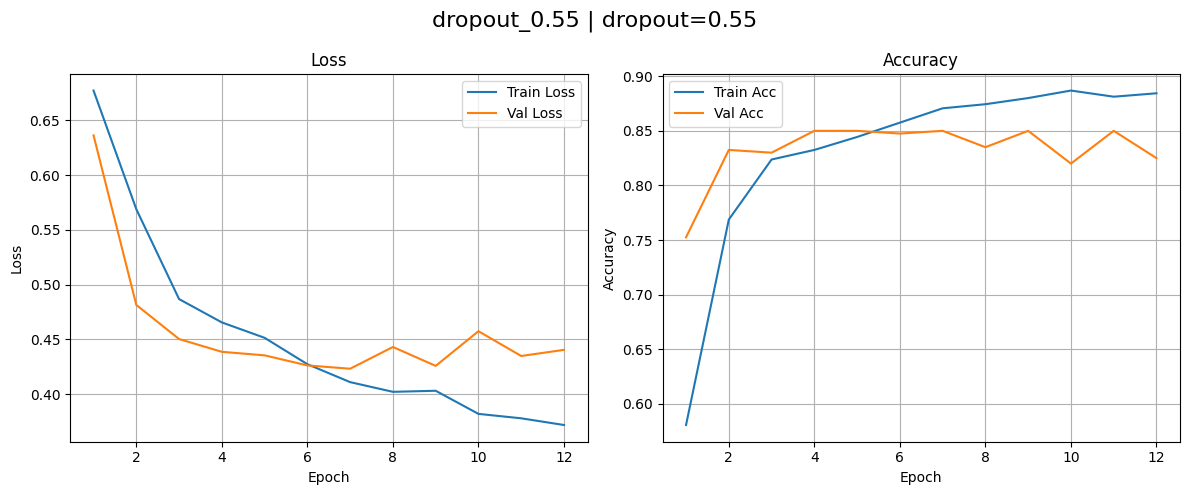

0.85
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.55, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


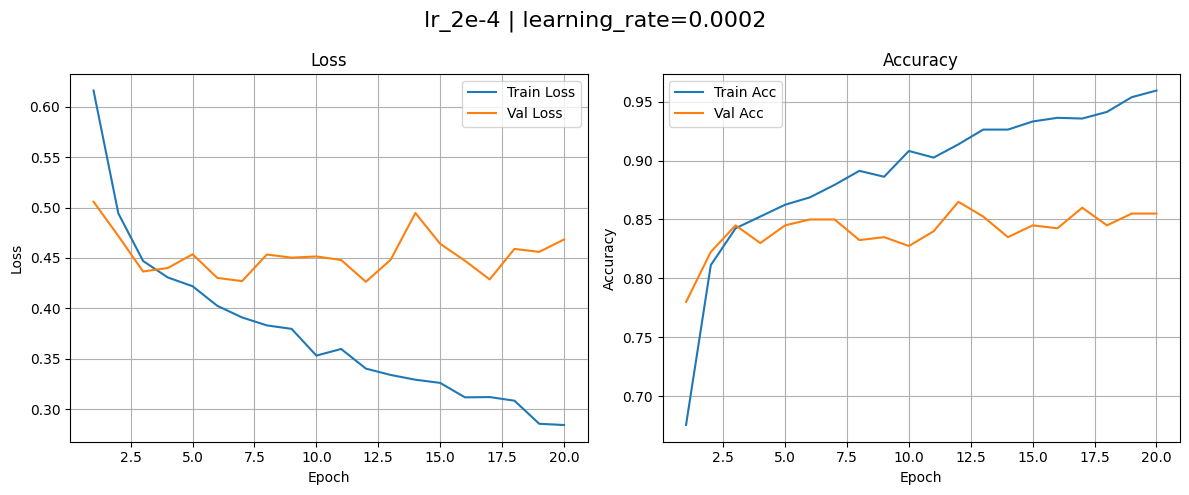

0.865
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0002, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


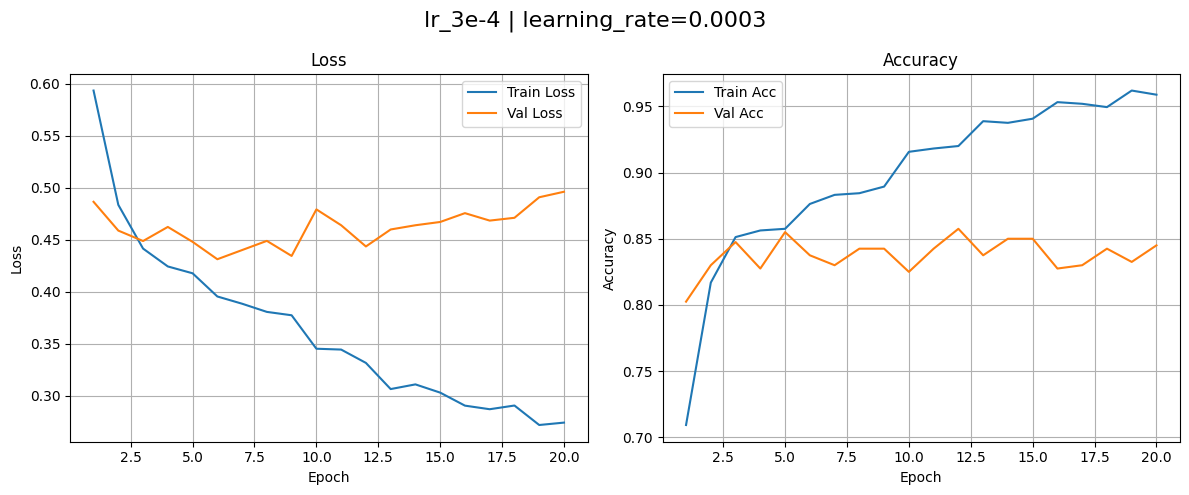

0.8575
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0003, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


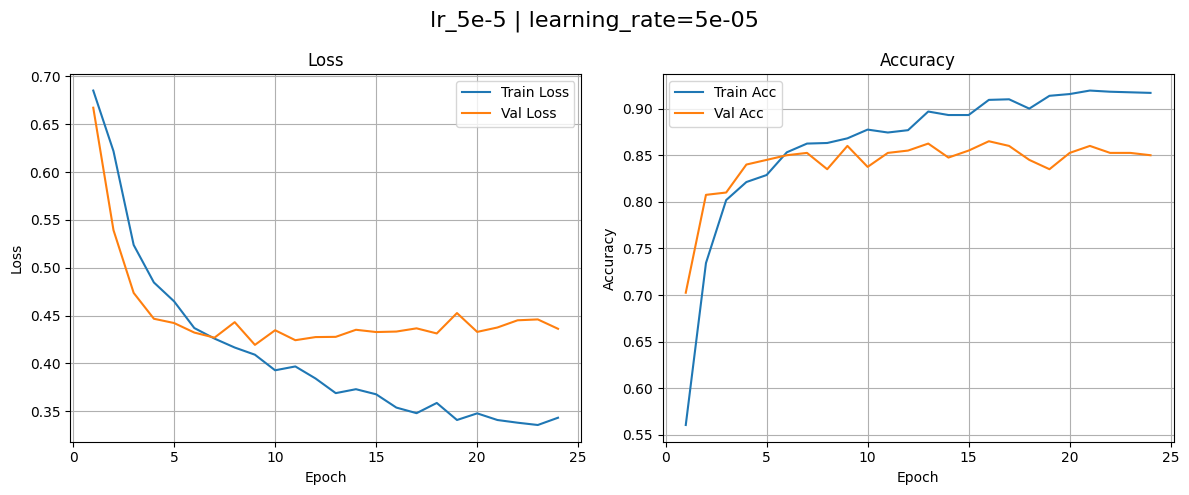

0.865
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 5e-05, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


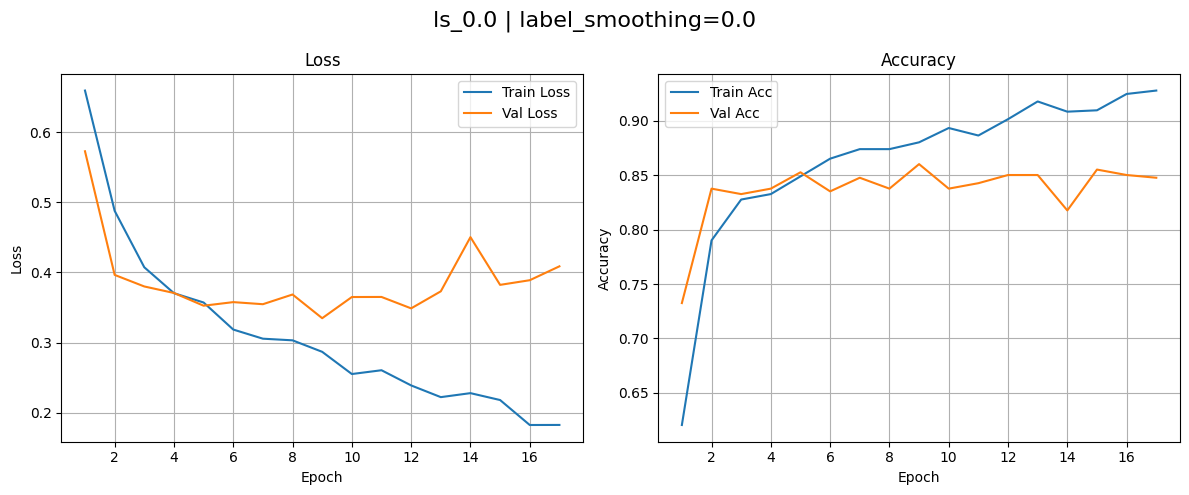

0.86
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.0, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


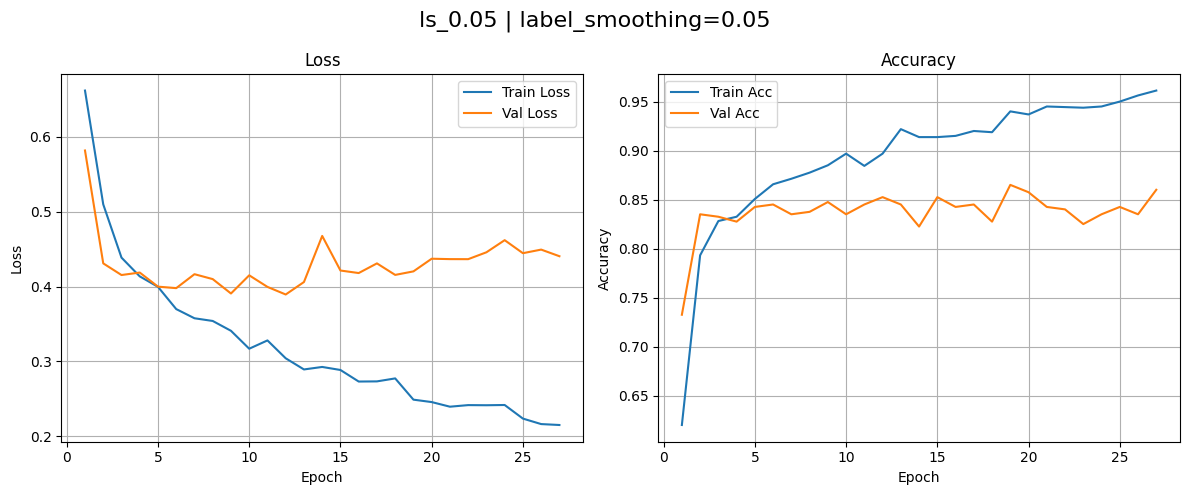

0.865
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.05, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


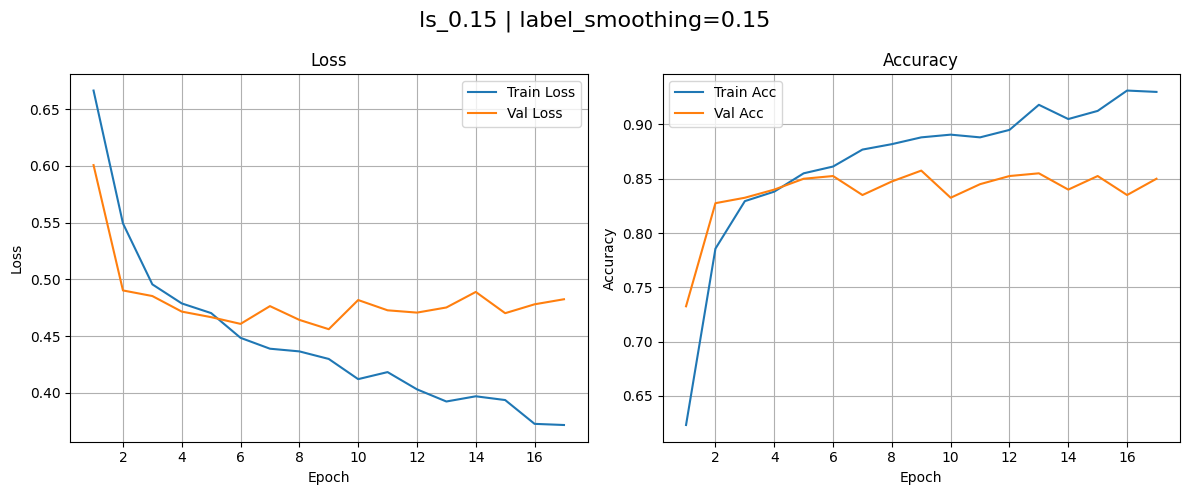

0.8575
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.15, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}
Skipping incomplete run: reg_1


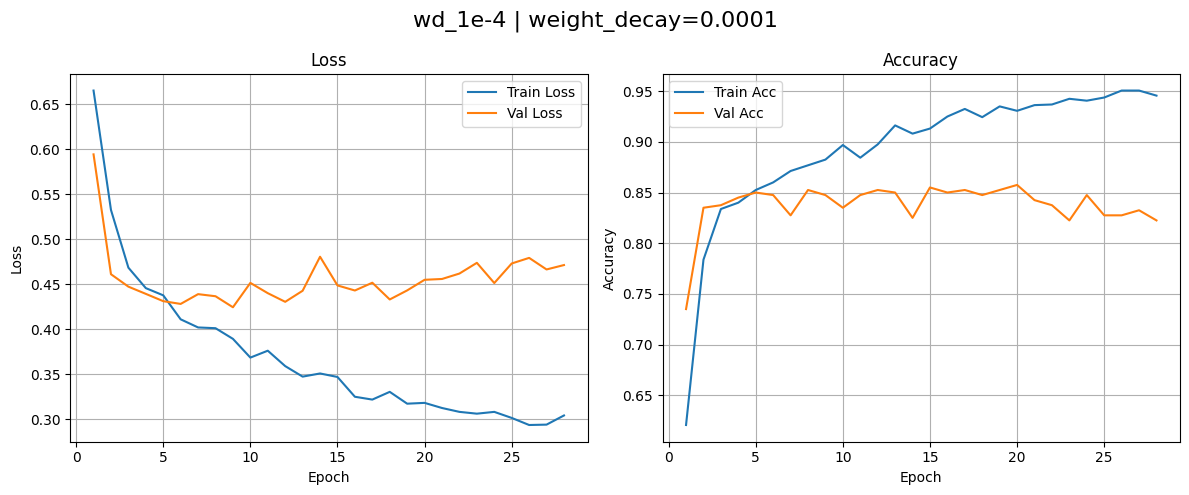

0.8575
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 0.0001, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


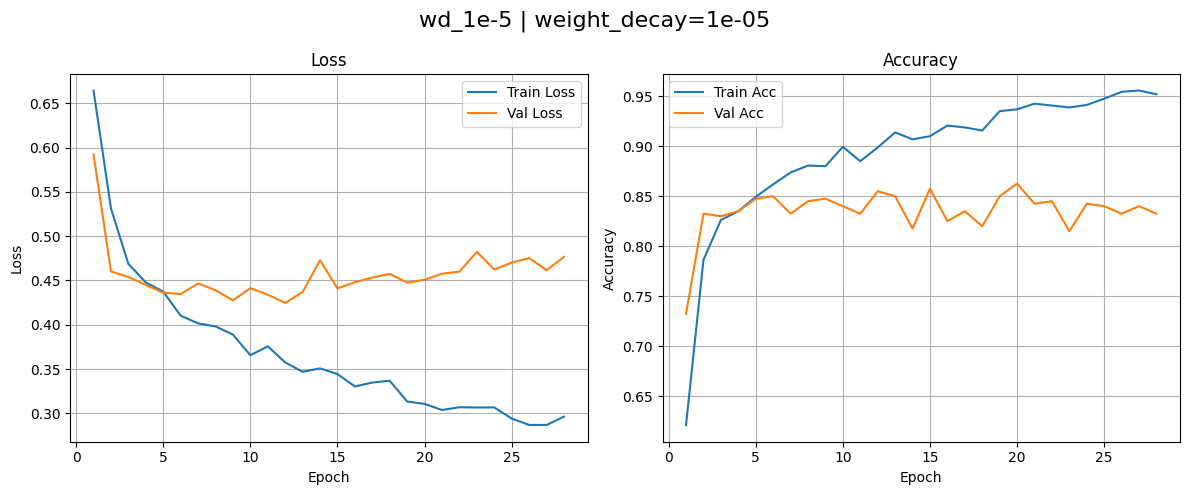

0.8625
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 1e-05, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


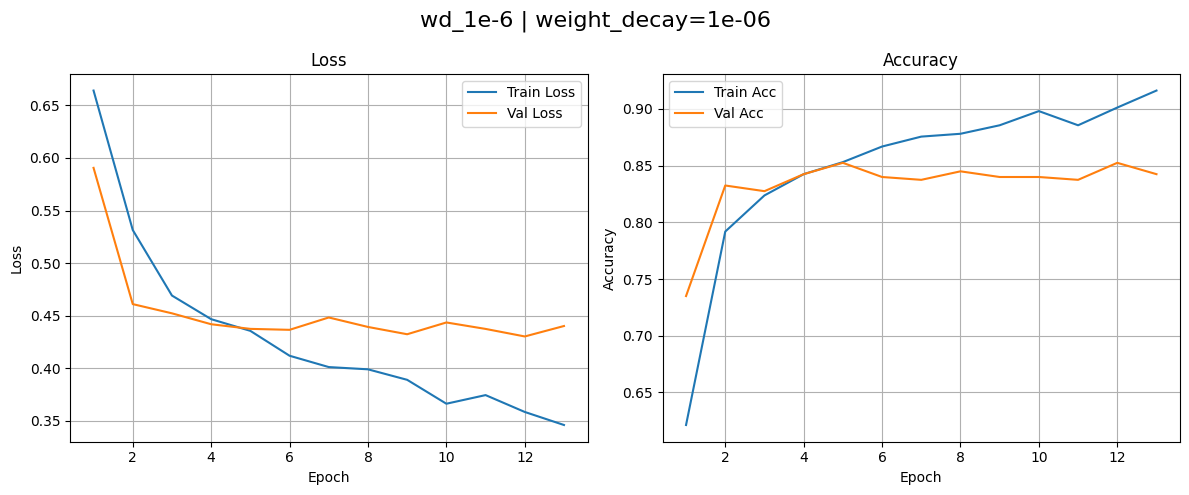

0.8525
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 1e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


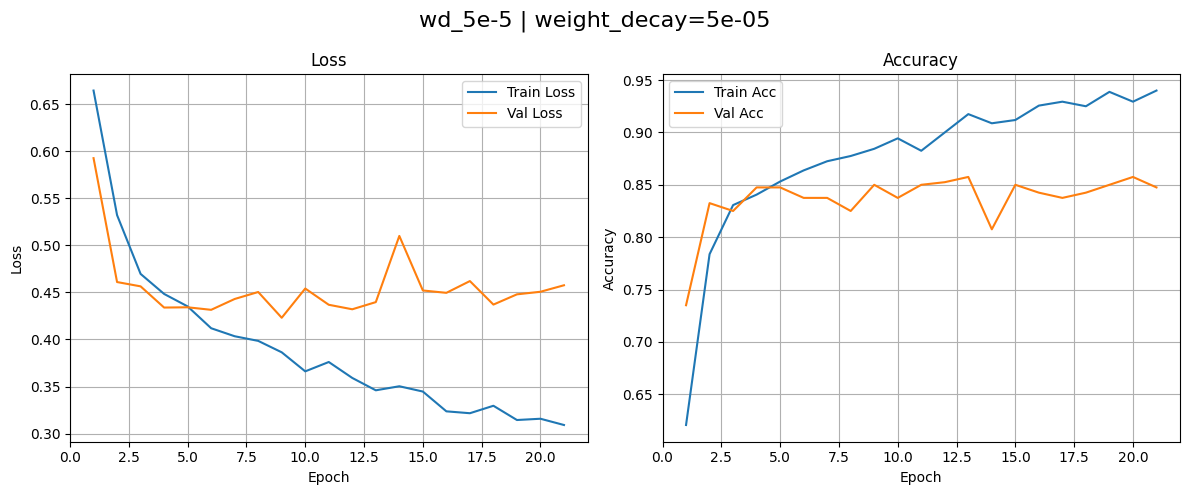

0.8575
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 8, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 8, 'weight_decay': 5e-05, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None, 'freeze_cnn_batchnorm': True}


In [5]:

plot_grid_search_results(experiment_root, default_config=default_config)

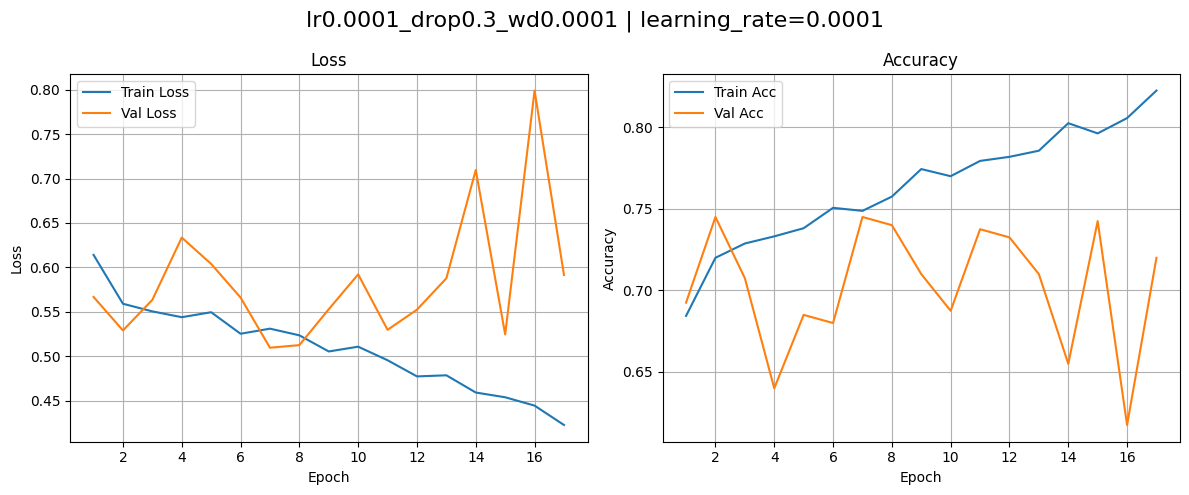

0.745
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


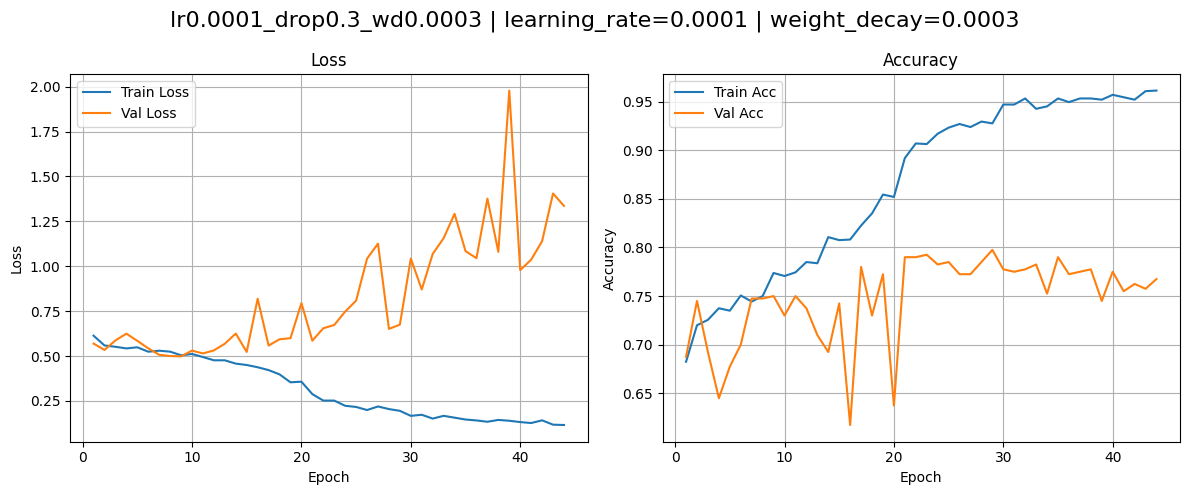

0.7975
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


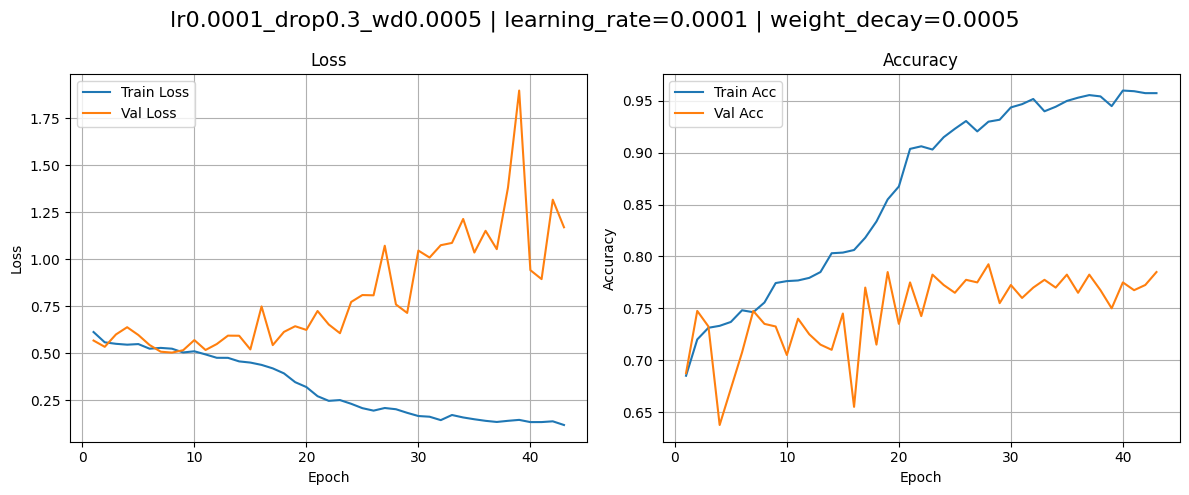

0.7925
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


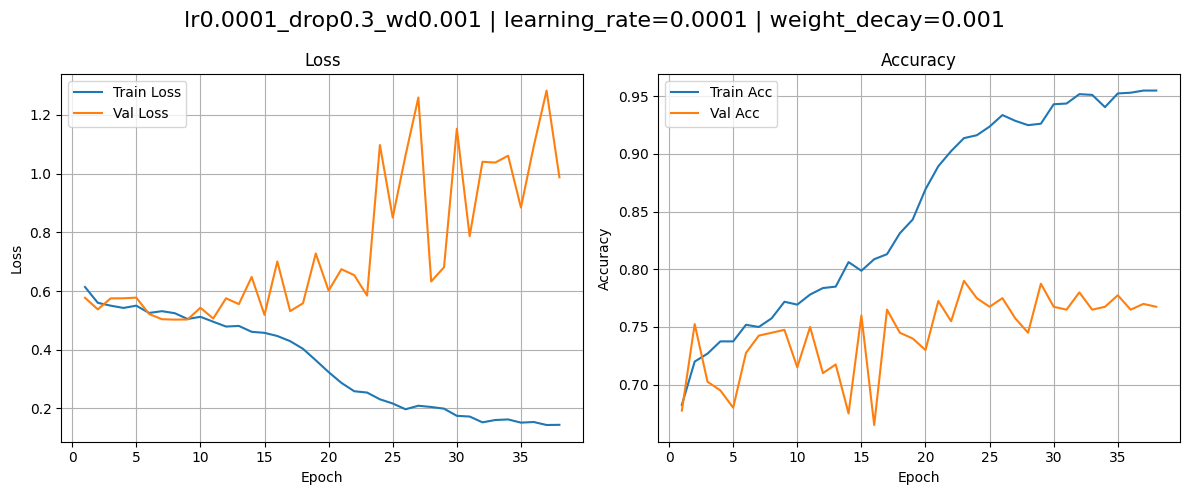

0.79
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


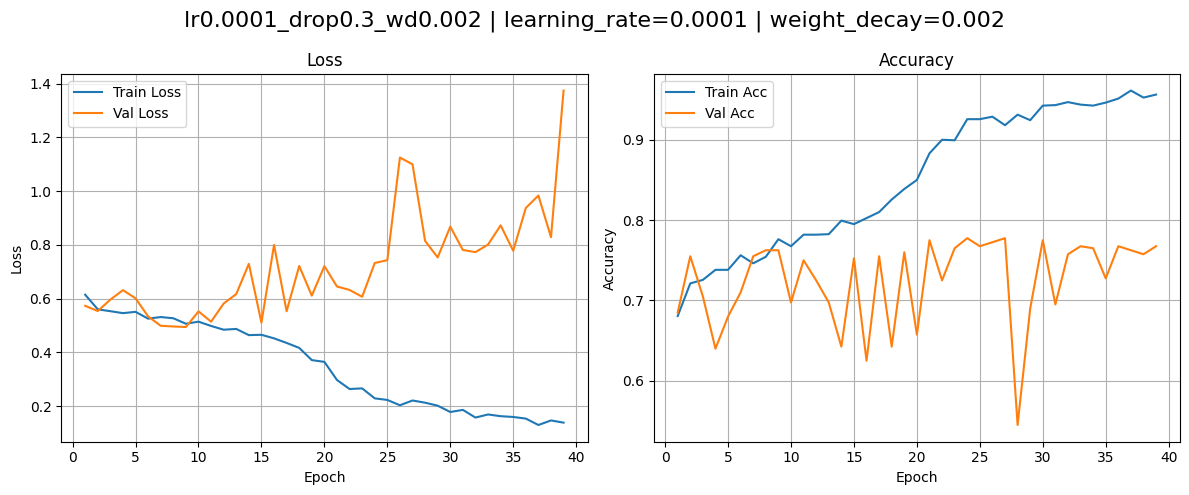

0.7775
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


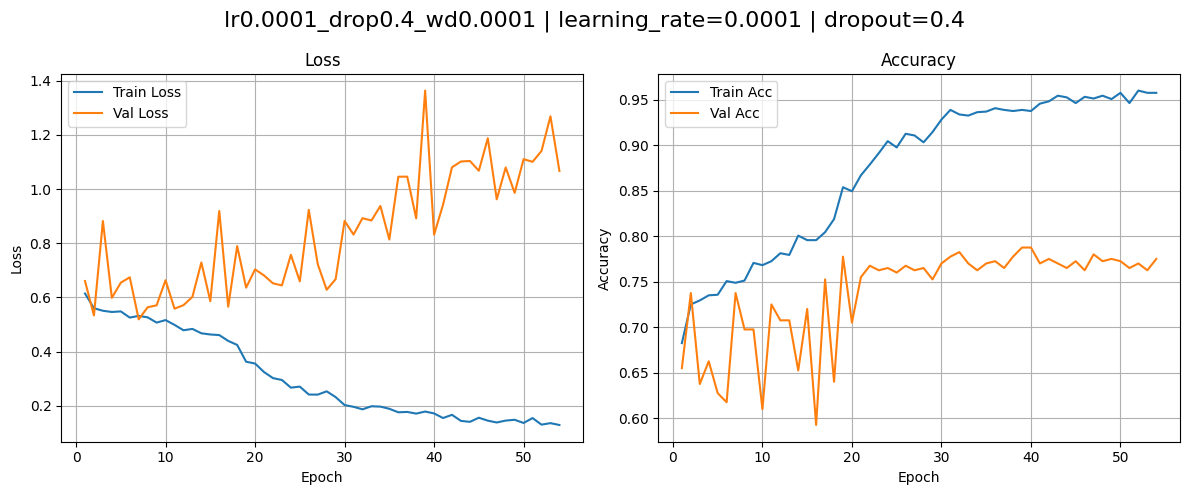

0.7875
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


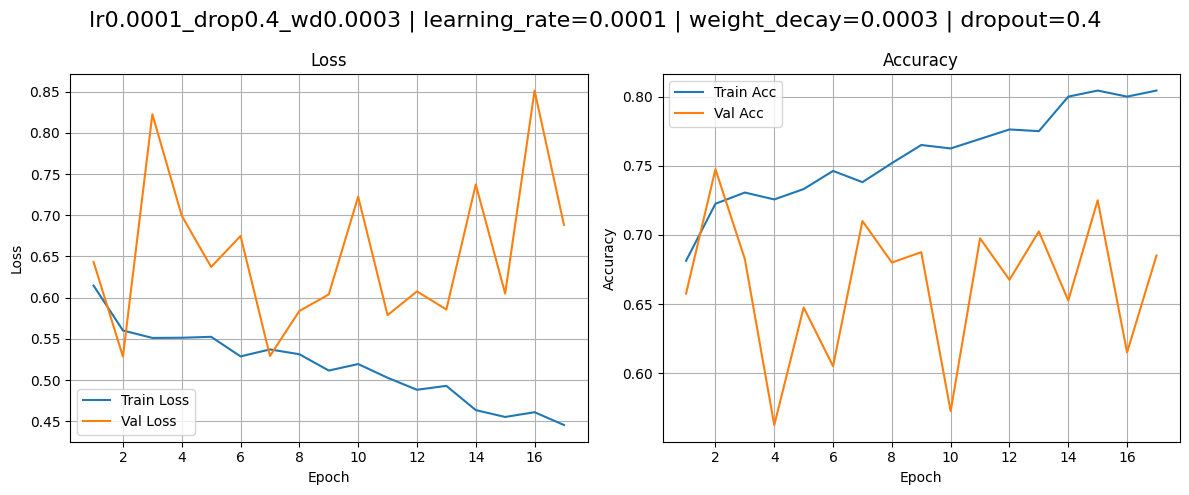

0.7475
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


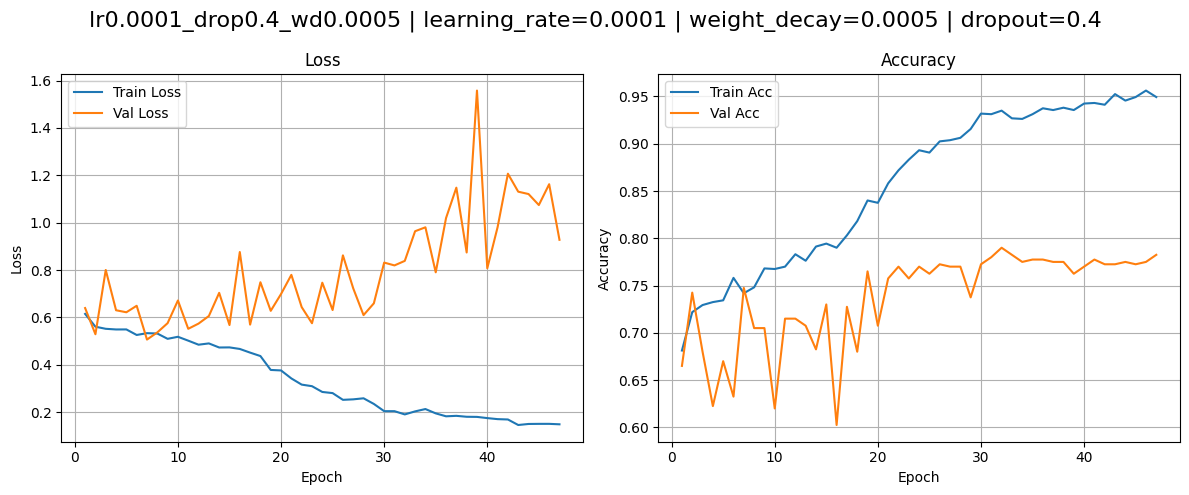

0.79
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


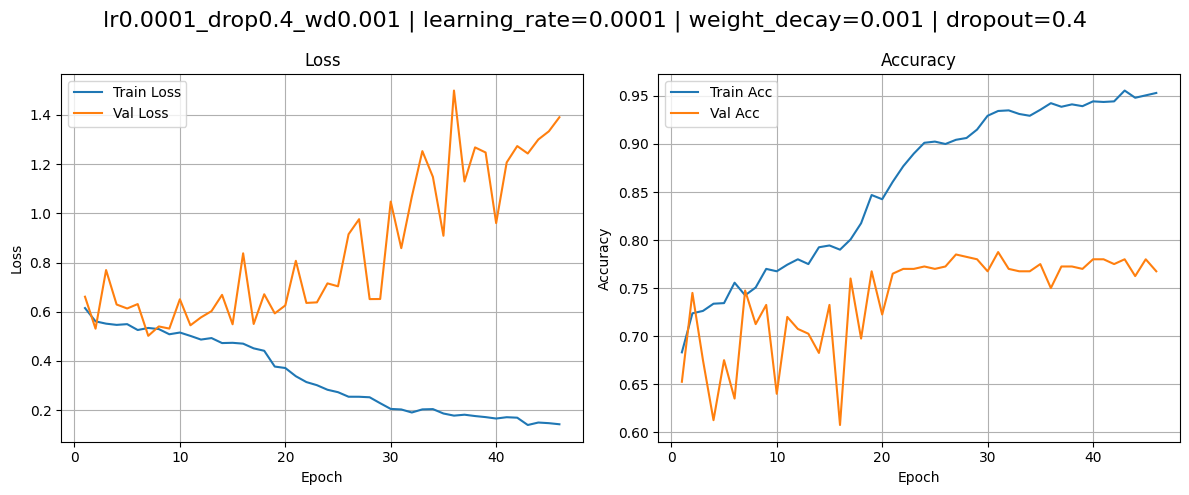

0.7875
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


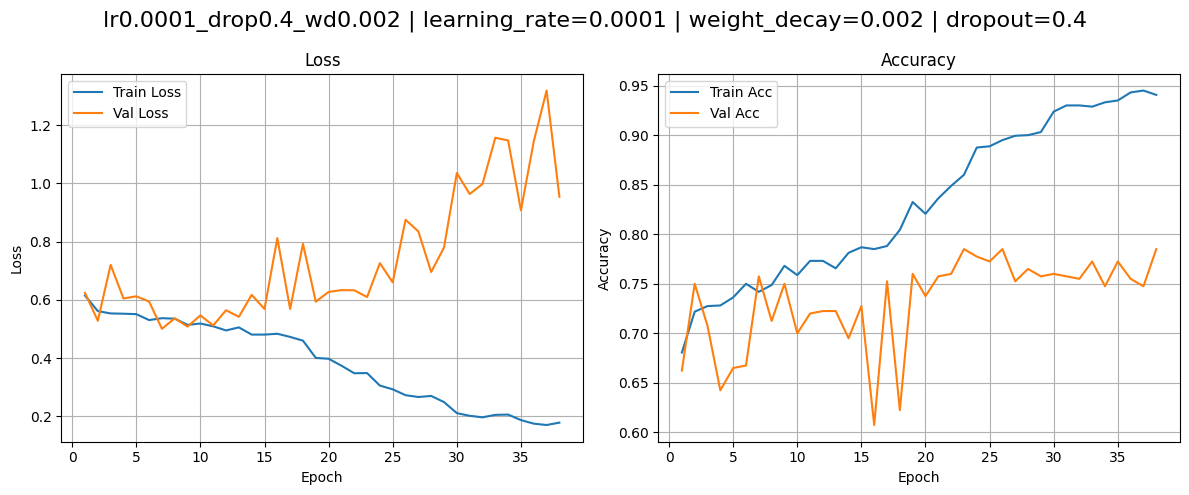

0.785
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


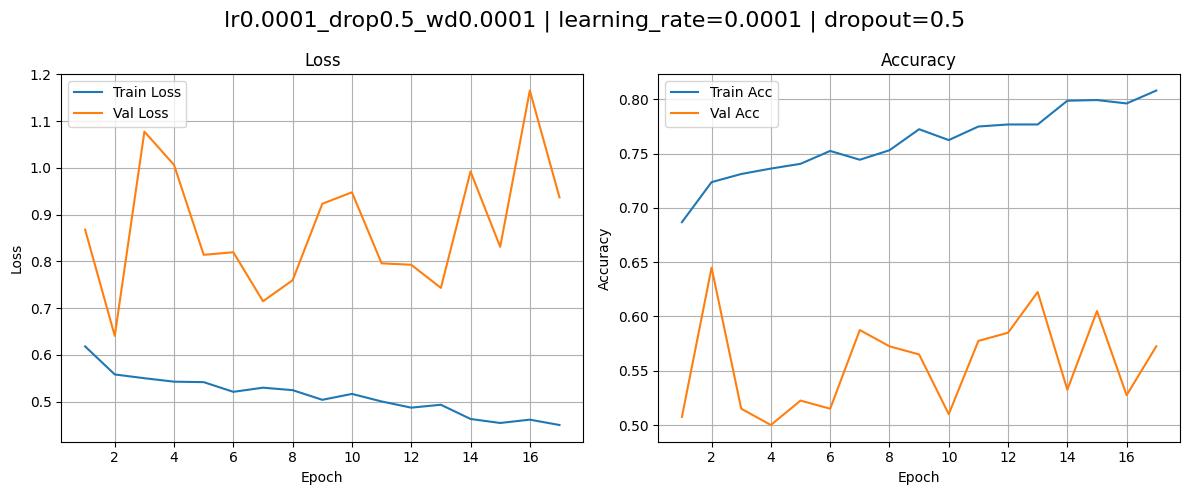

0.645
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


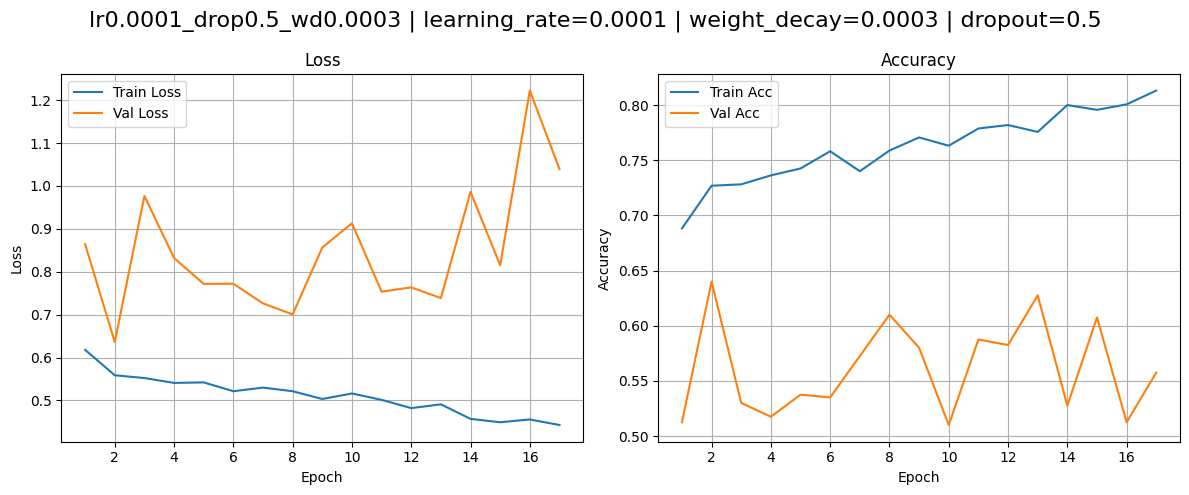

0.64
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


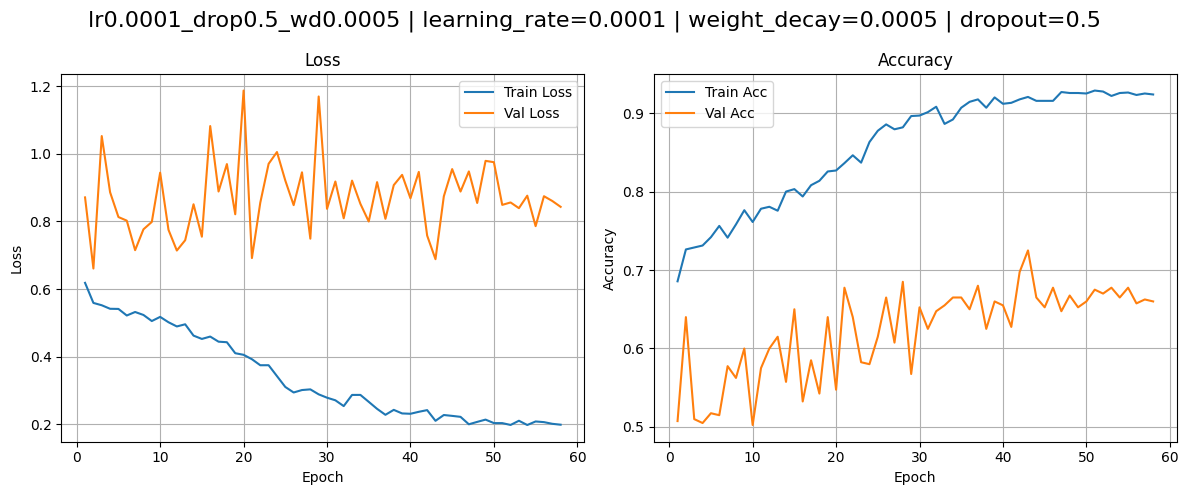

0.725
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


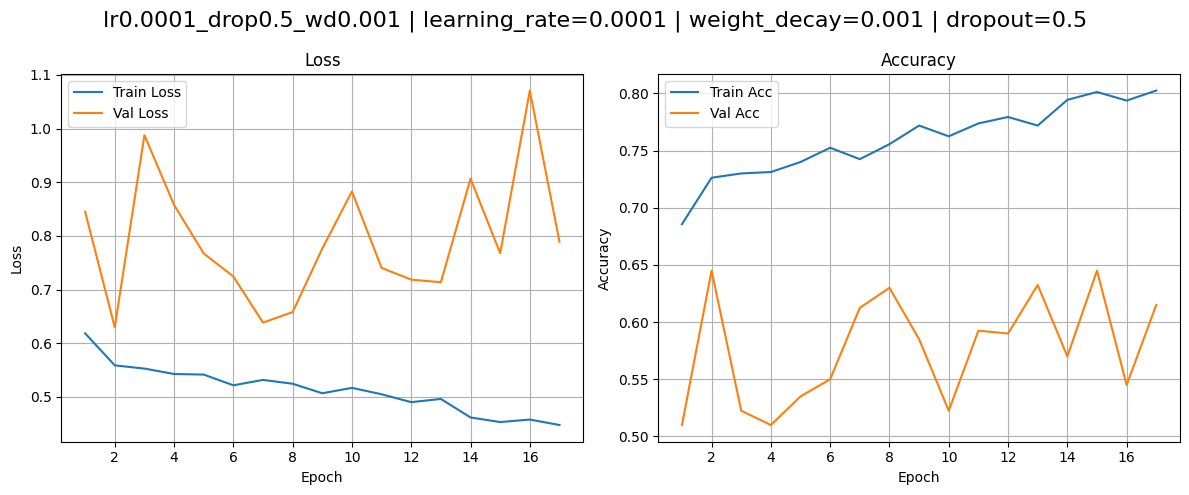

0.645
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


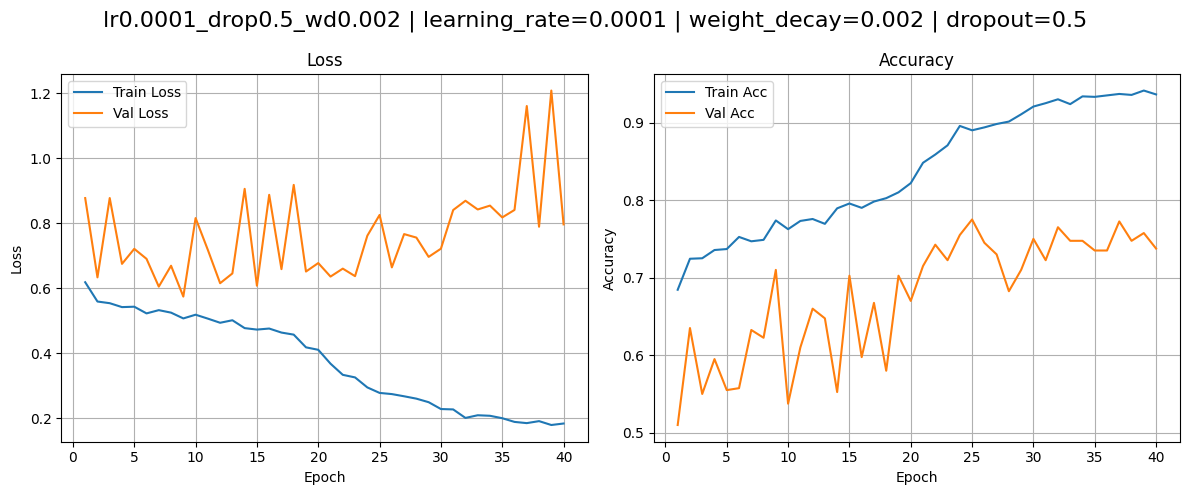

0.775
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


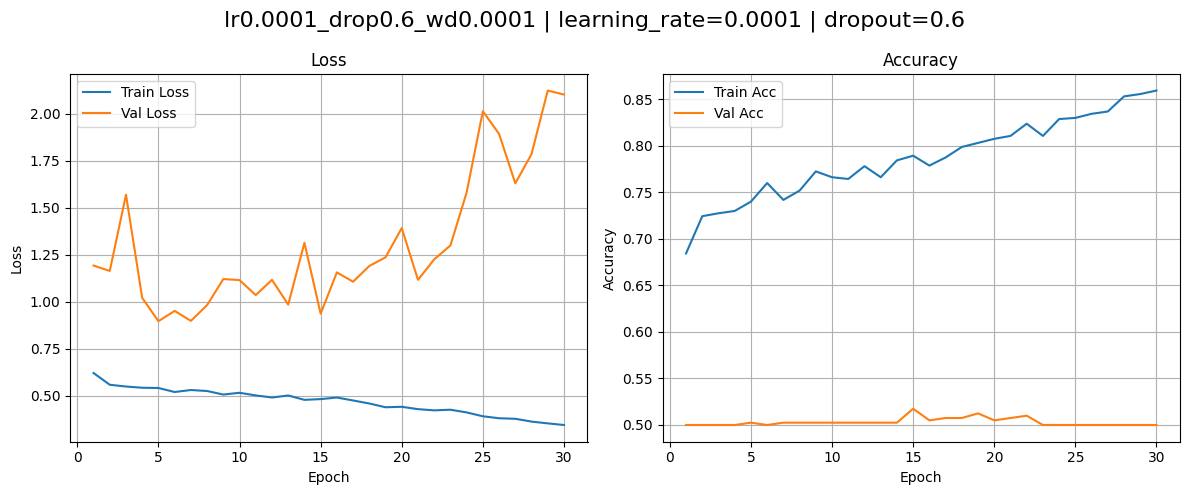

0.5175
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


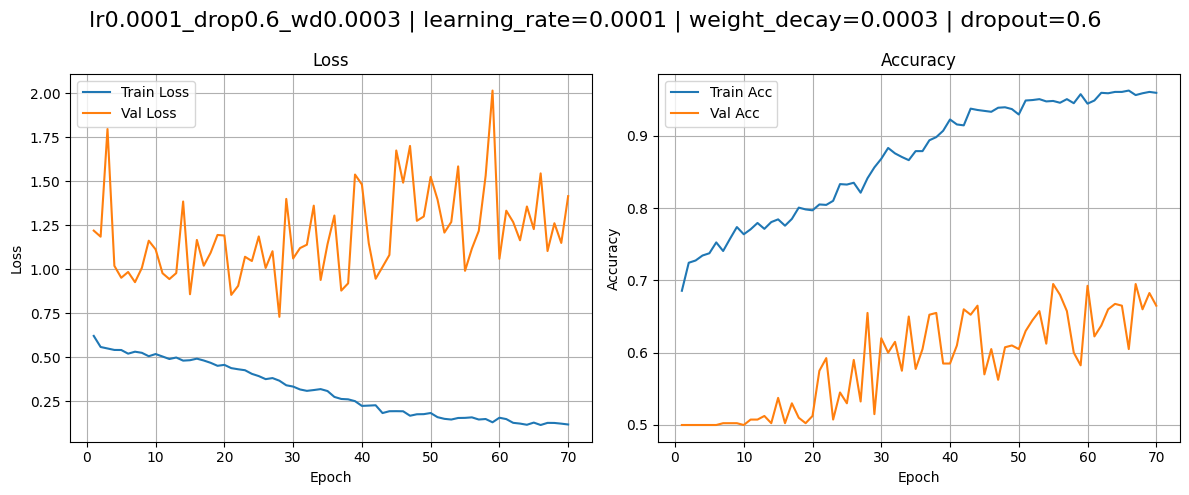

0.695
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


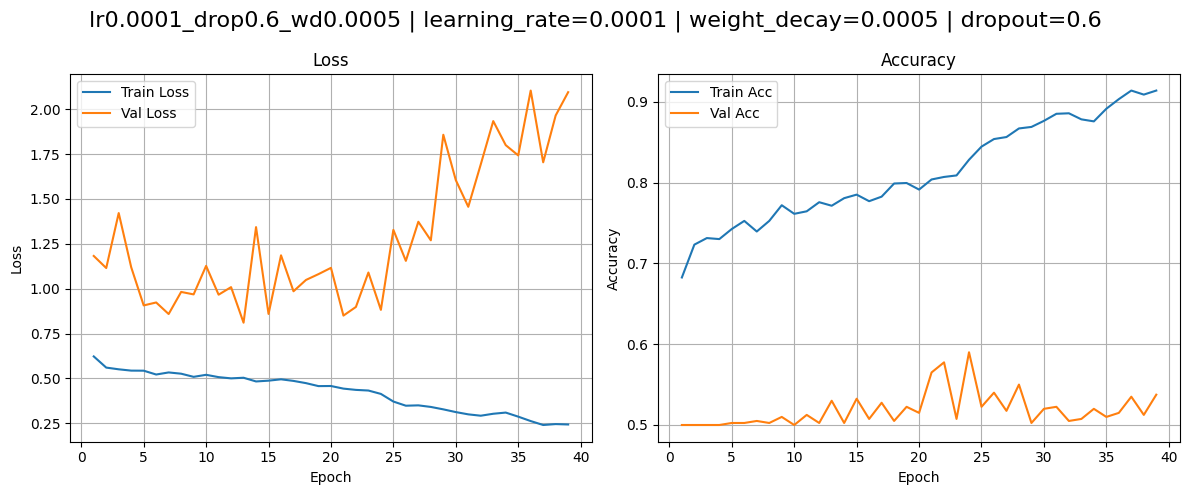

0.59
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


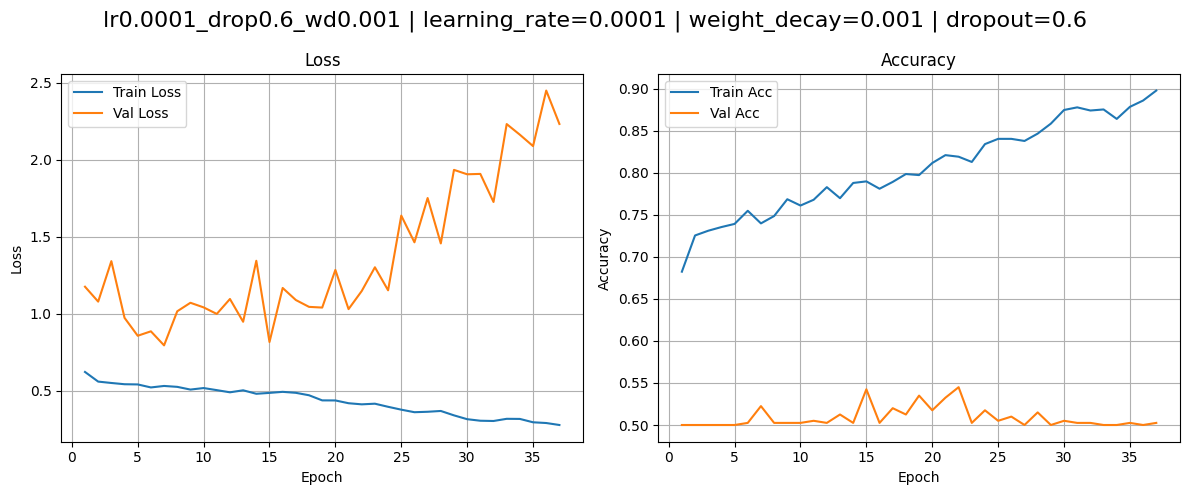

0.545
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


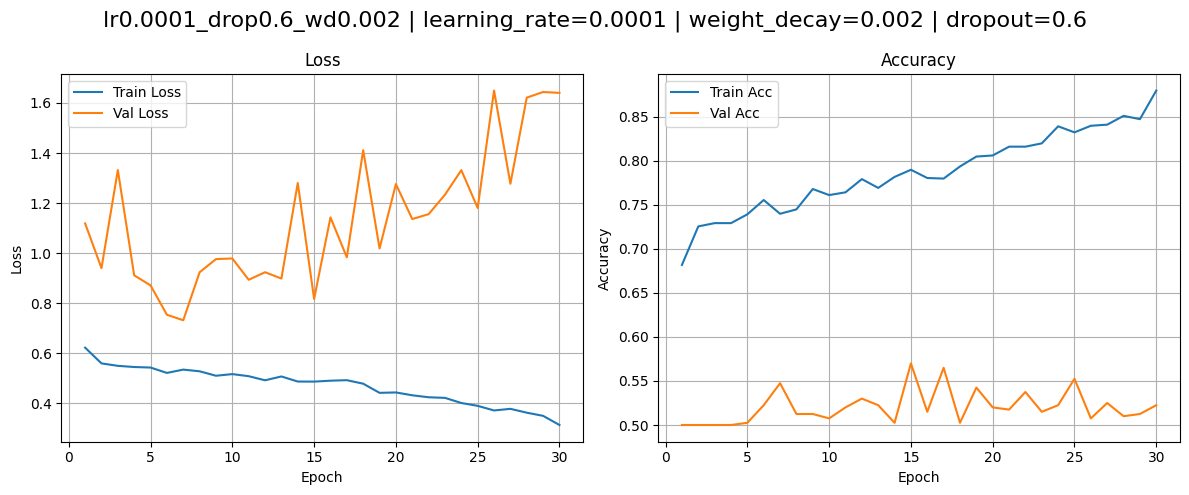

0.57
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


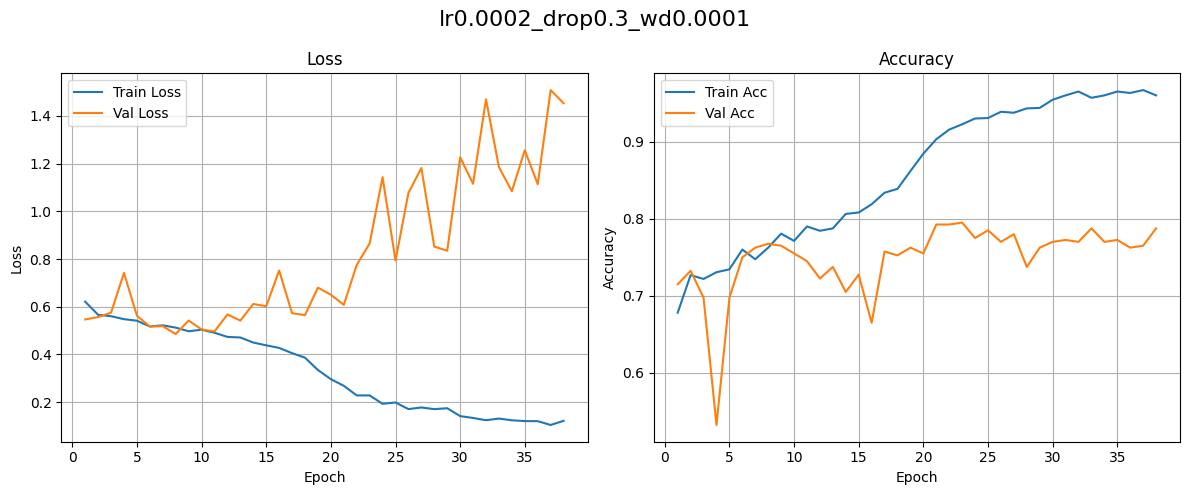

0.795
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


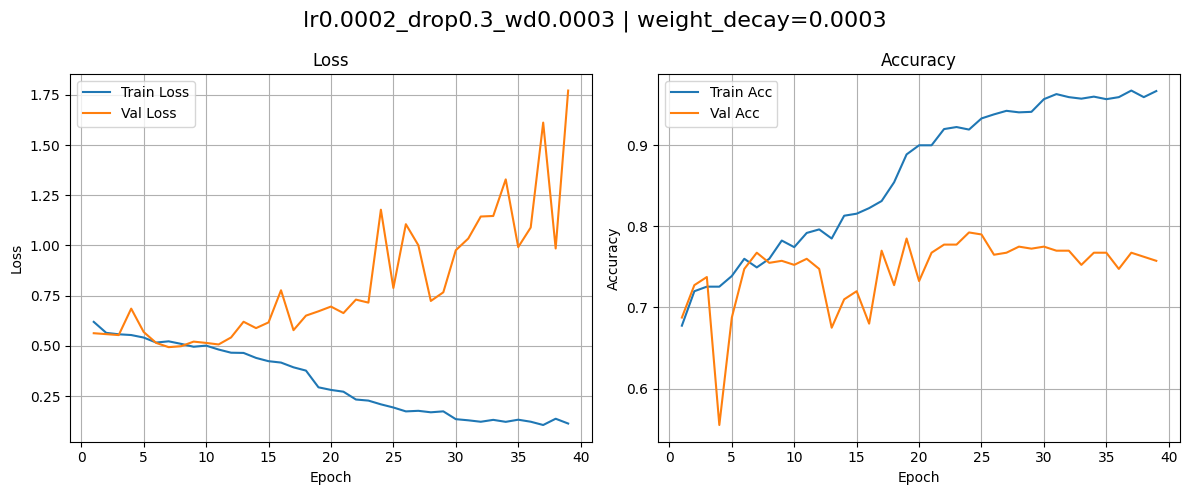

0.7925
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


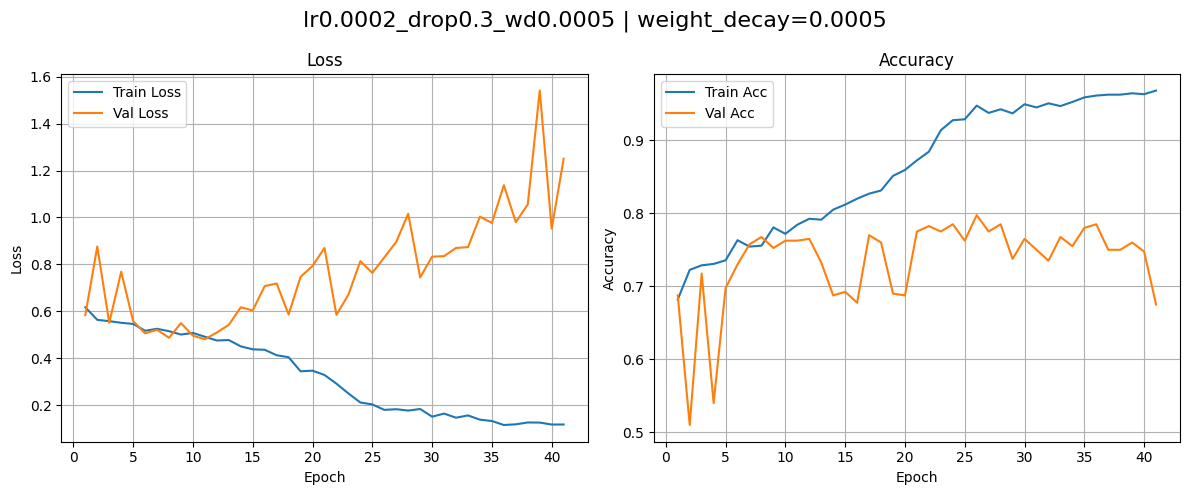

0.7975
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


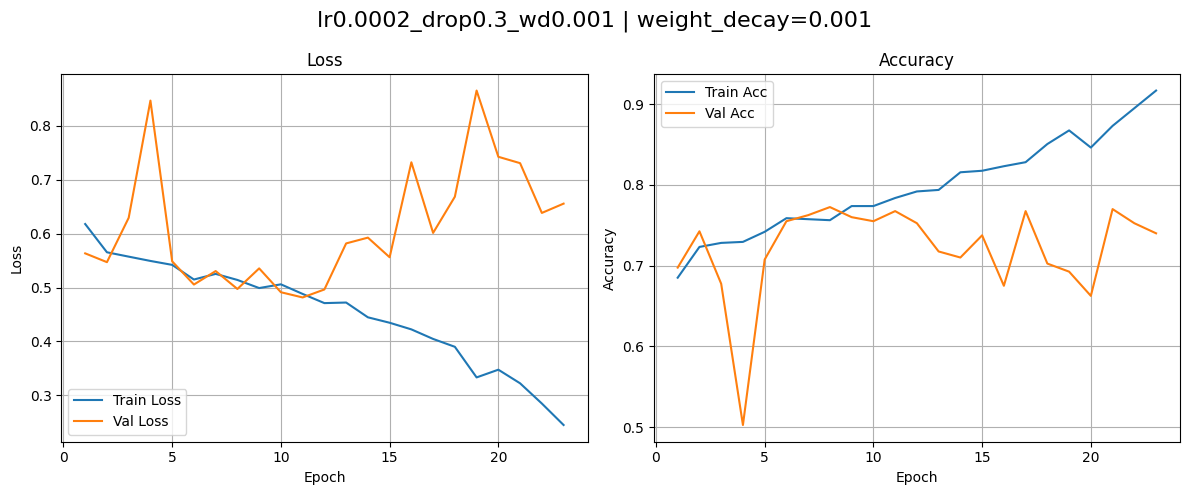

0.7725
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


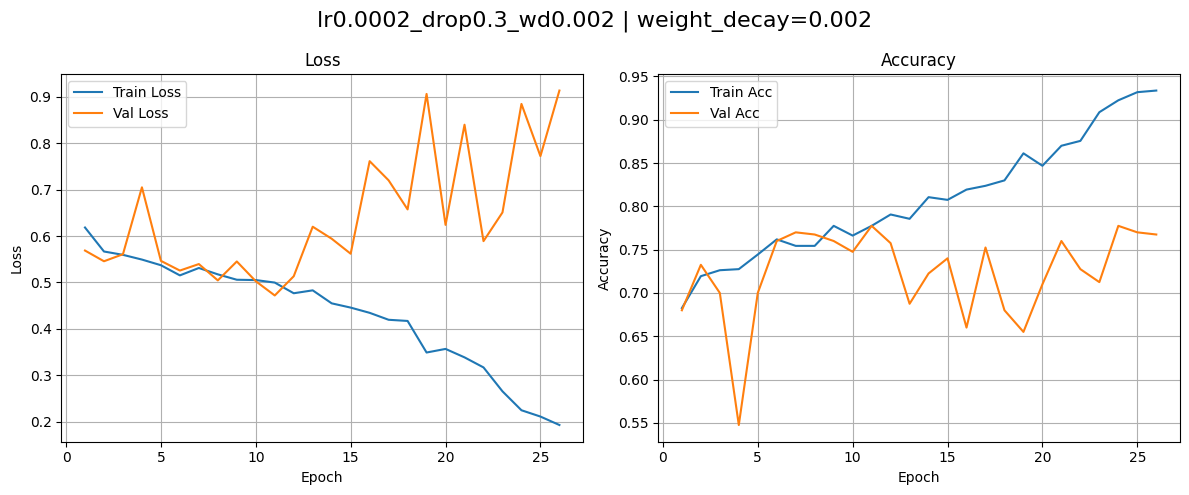

0.7775
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


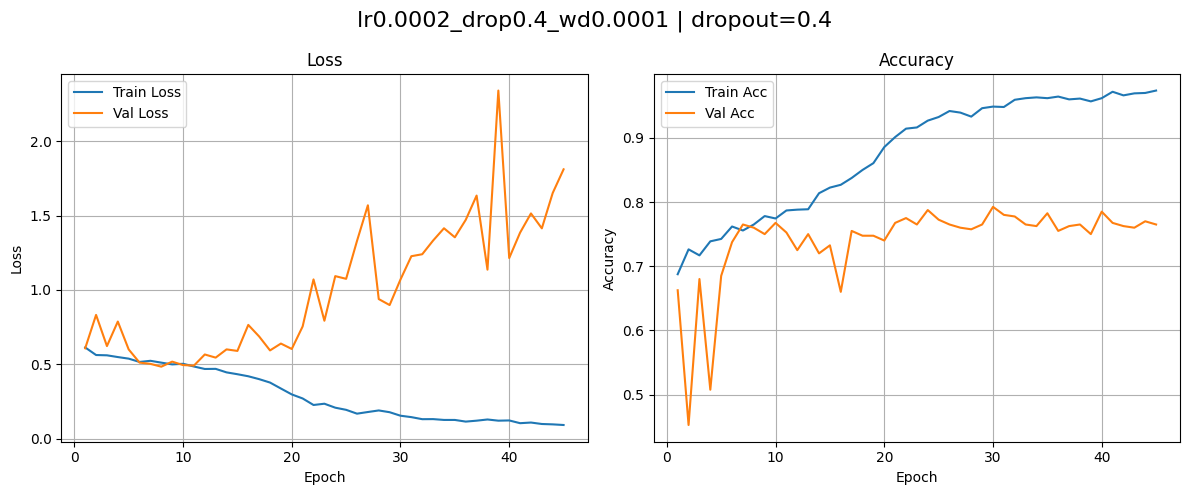

0.7925
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


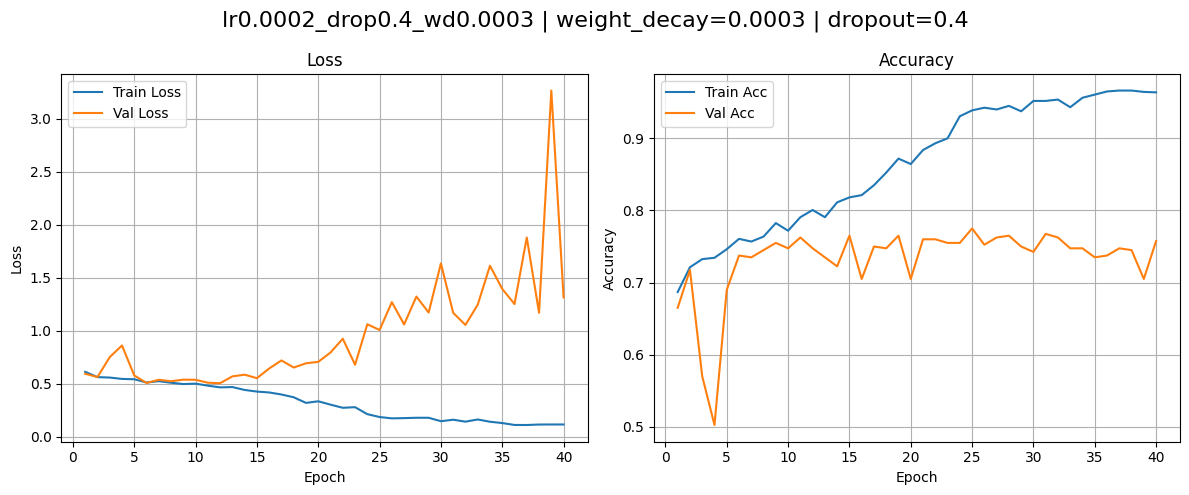

0.775
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


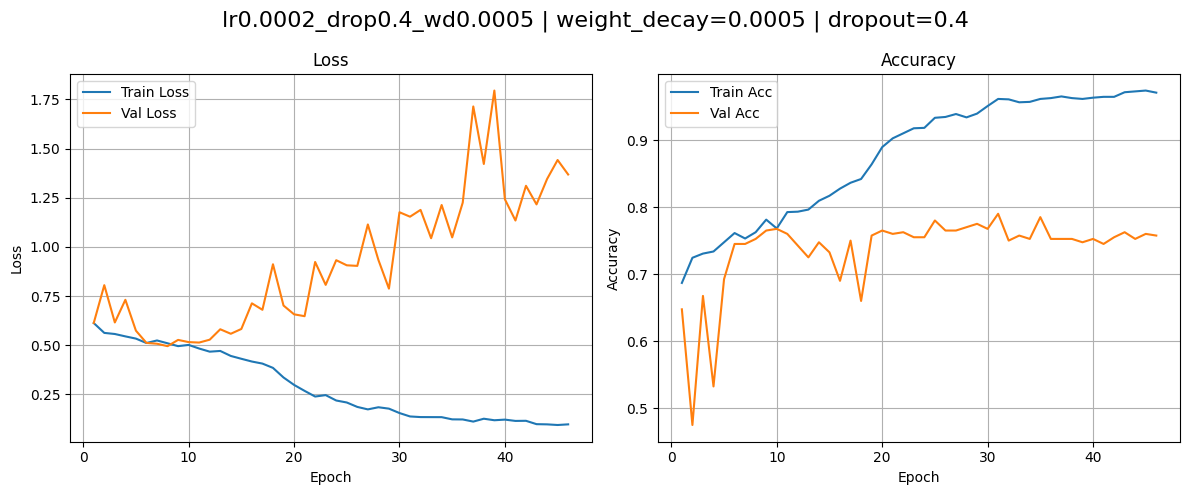

0.79
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


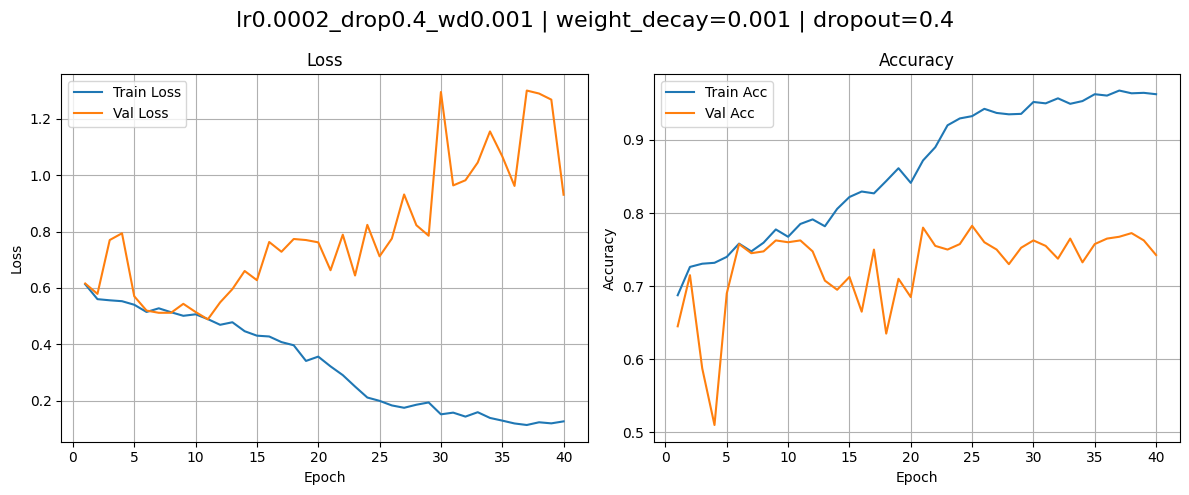

0.7825
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


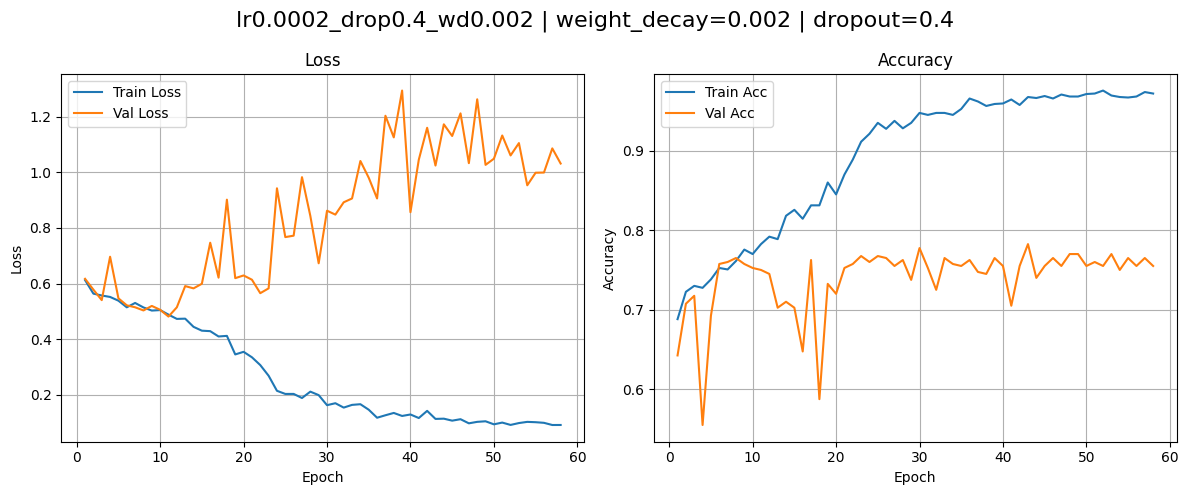

0.7825
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


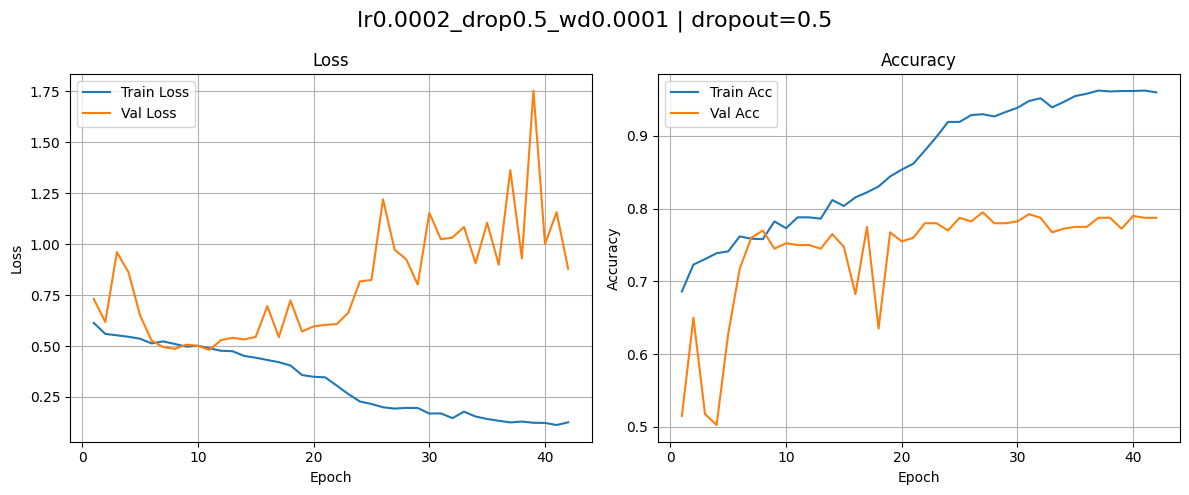

0.795
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


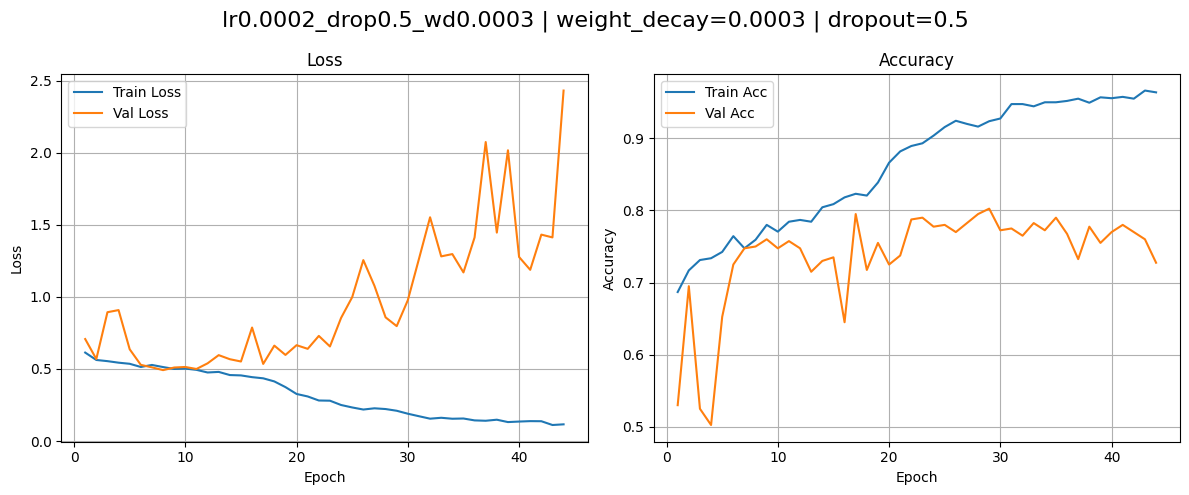

0.8025
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


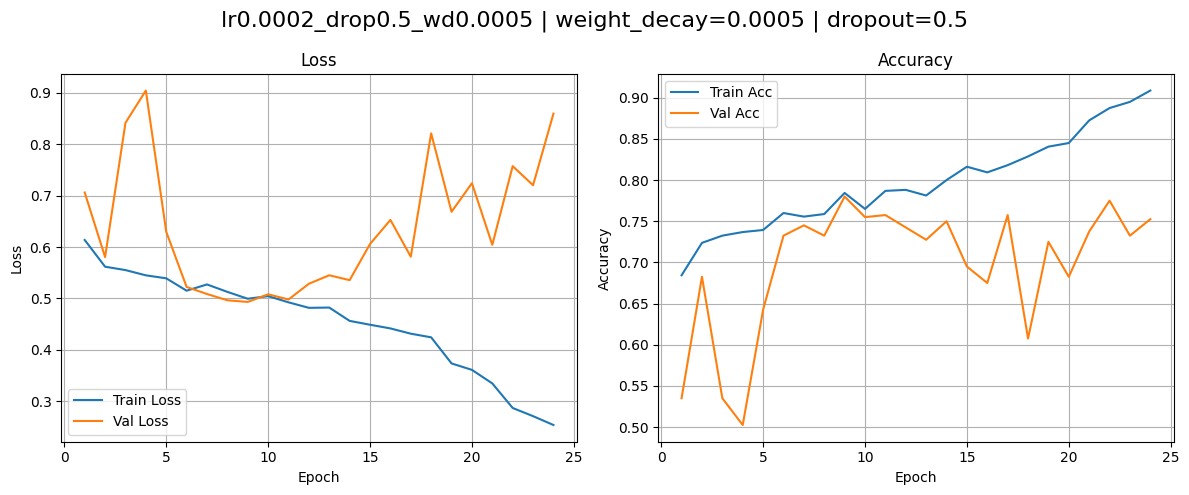

0.78
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}
Skipping incomplete run: lr0.0002_drop0.5_wd0.001


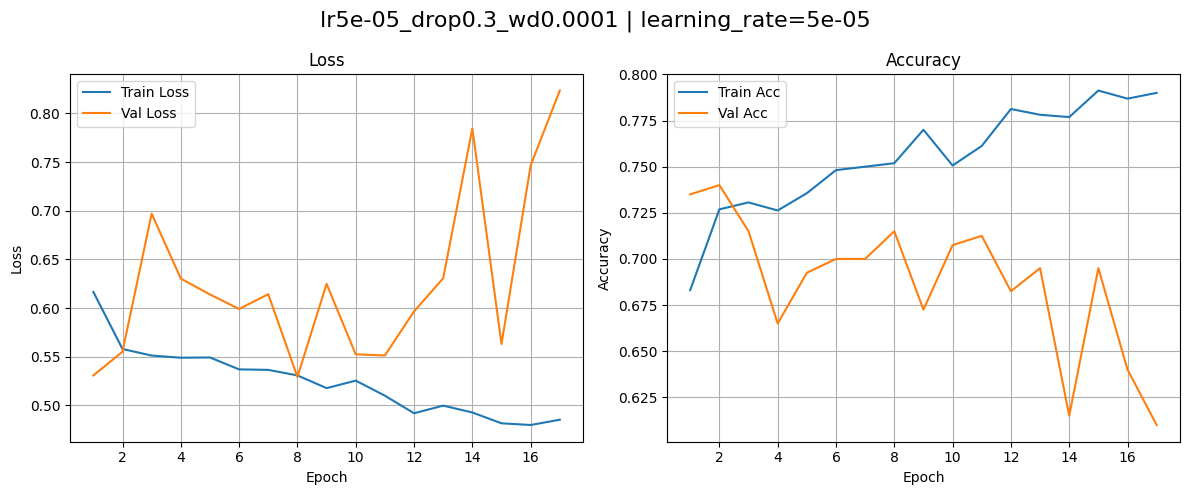

0.74
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


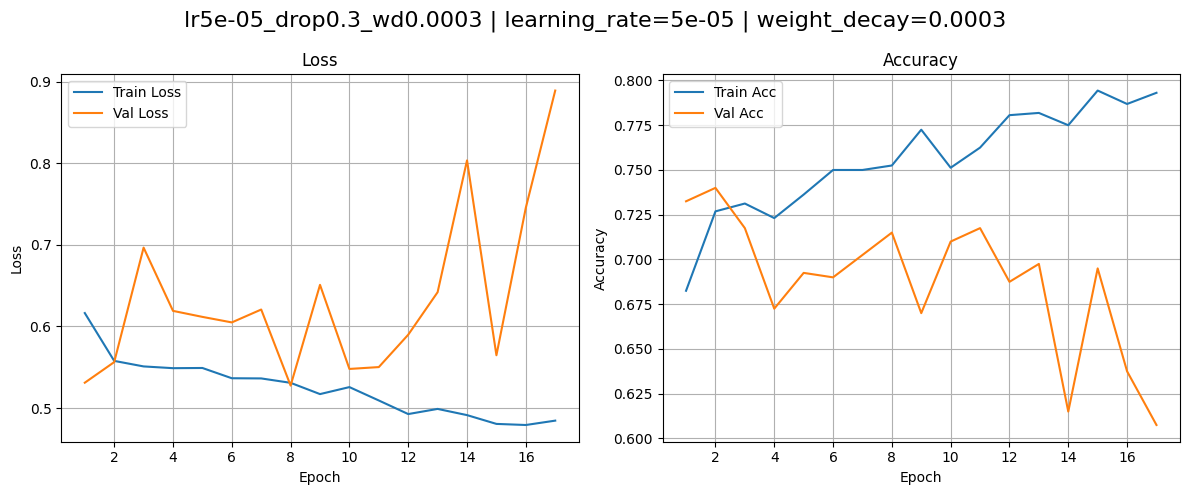

0.74
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


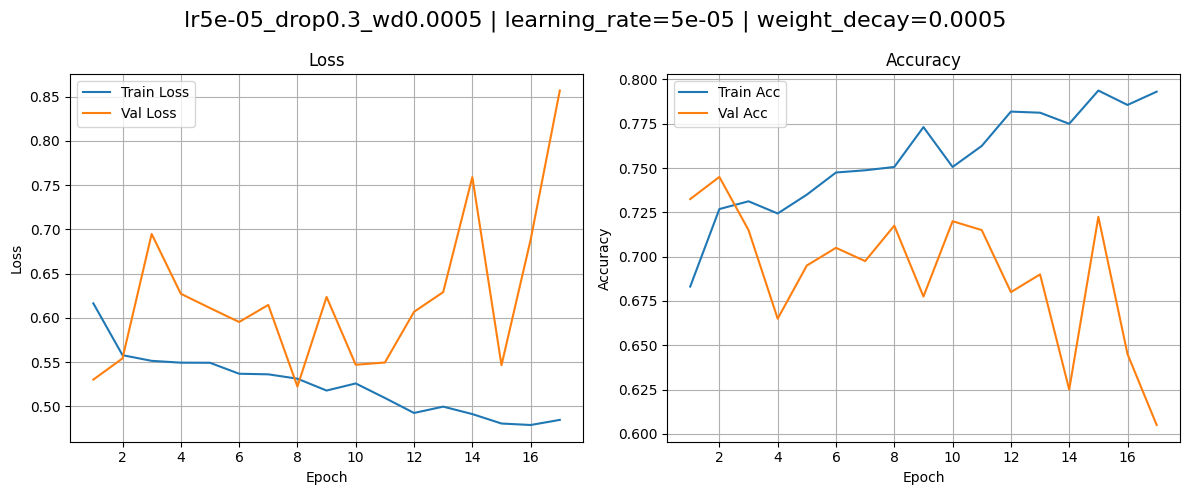

0.745
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


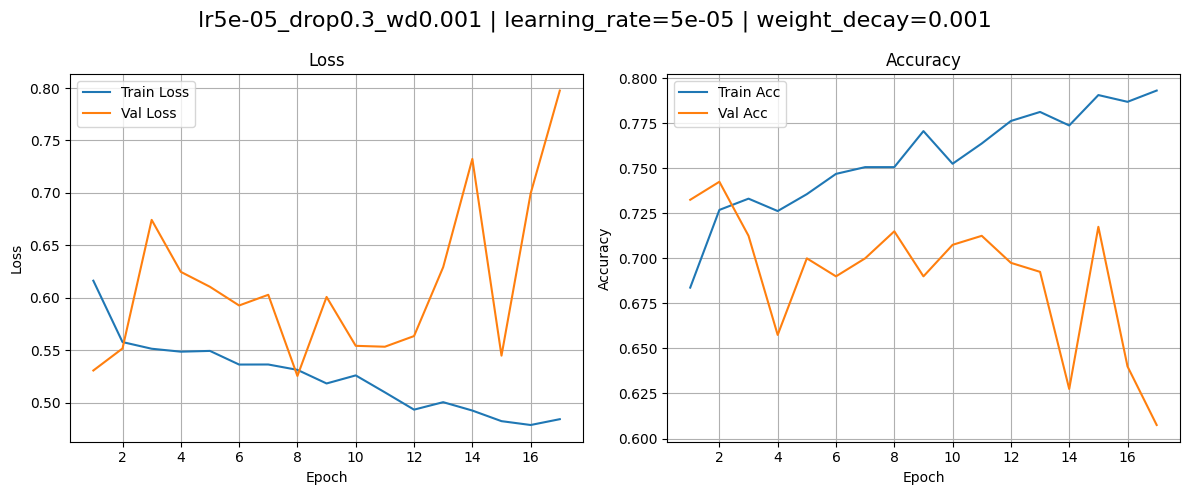

0.7425
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


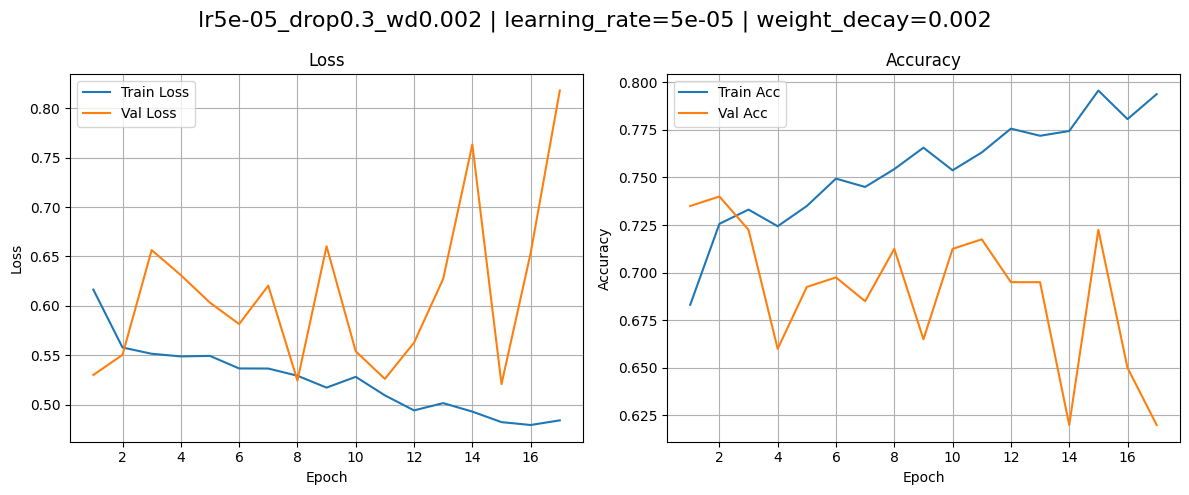

0.74
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


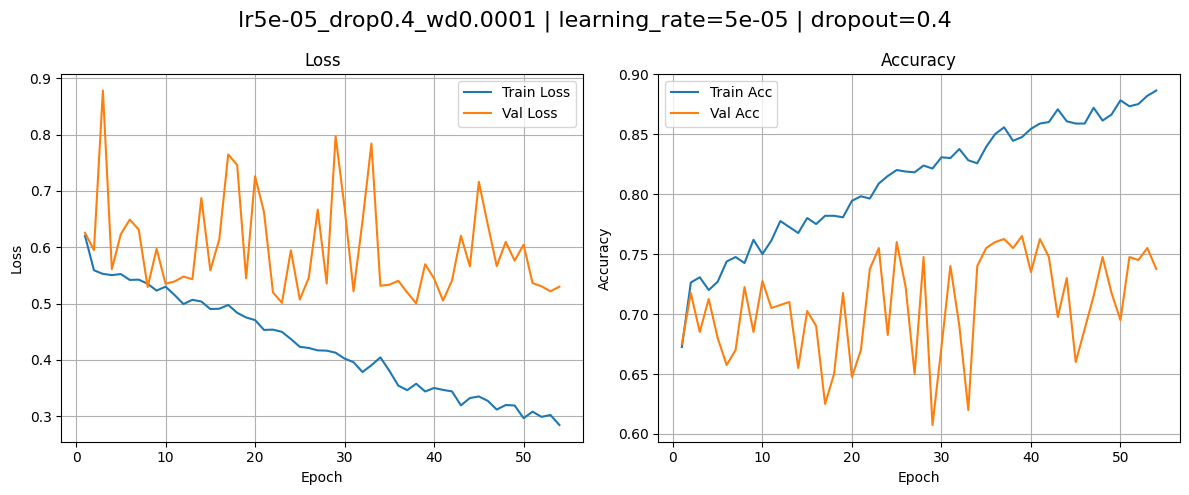

0.765
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


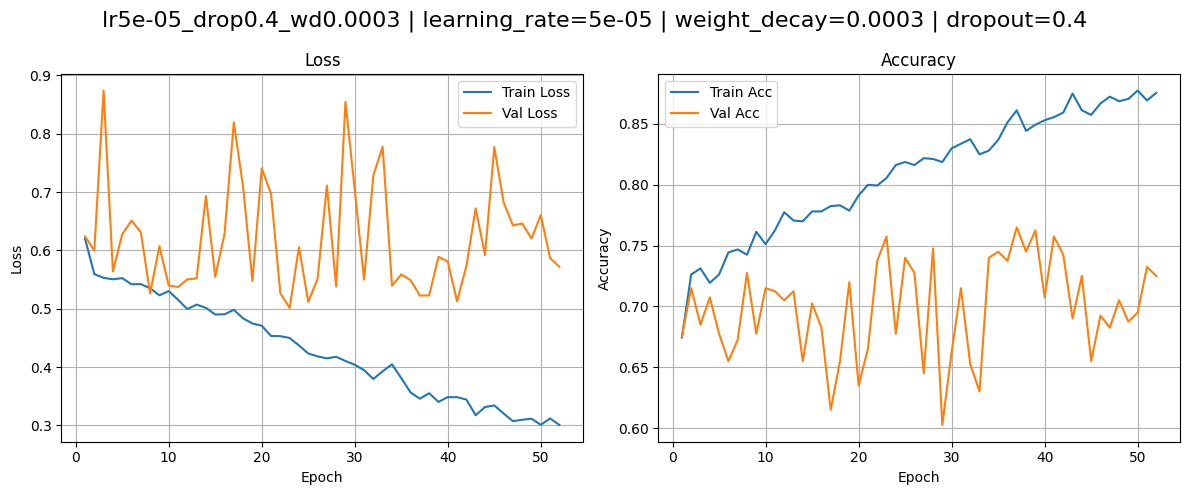

0.765
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


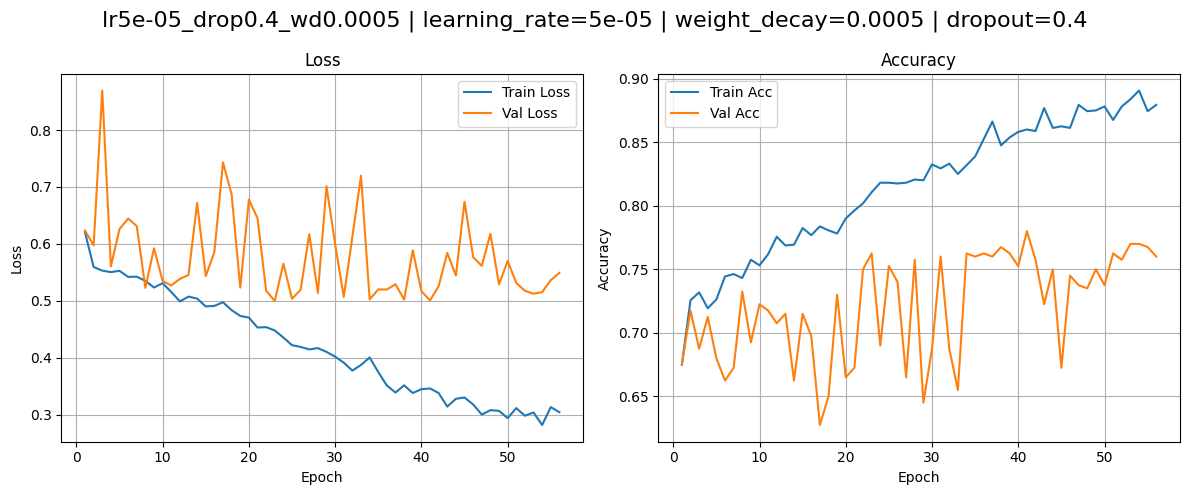

0.78
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


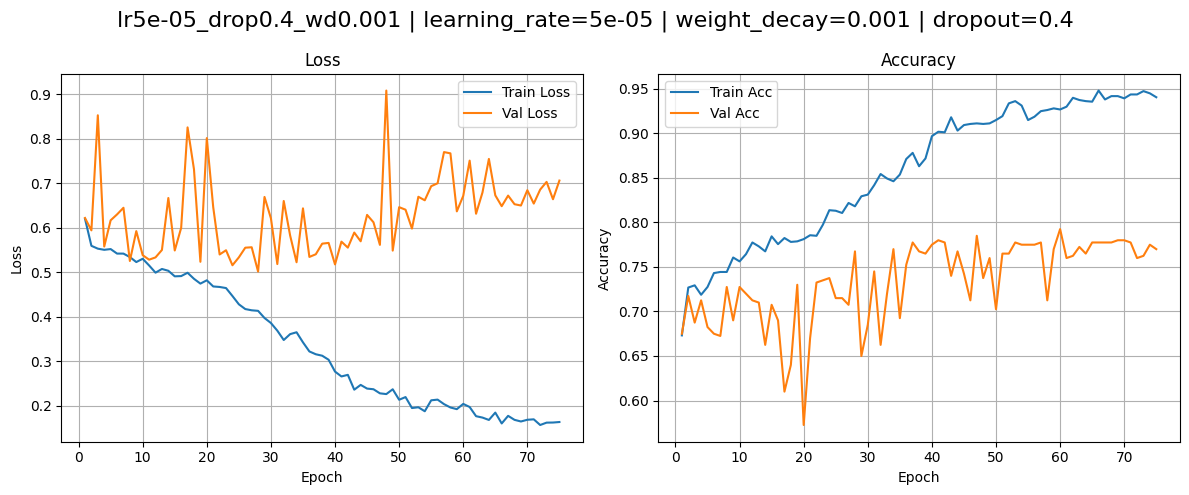

0.7925
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


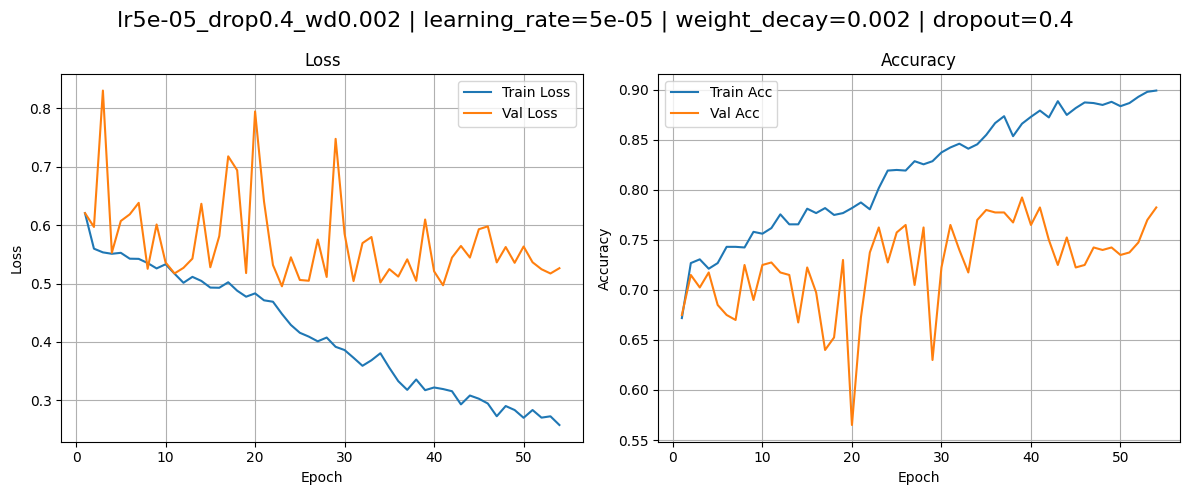

0.7925
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


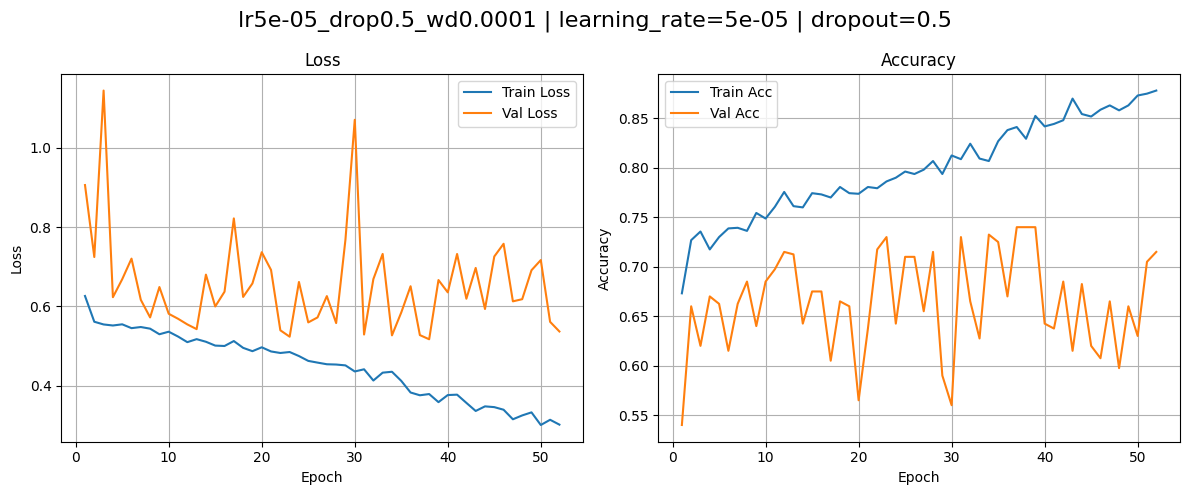

0.74
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


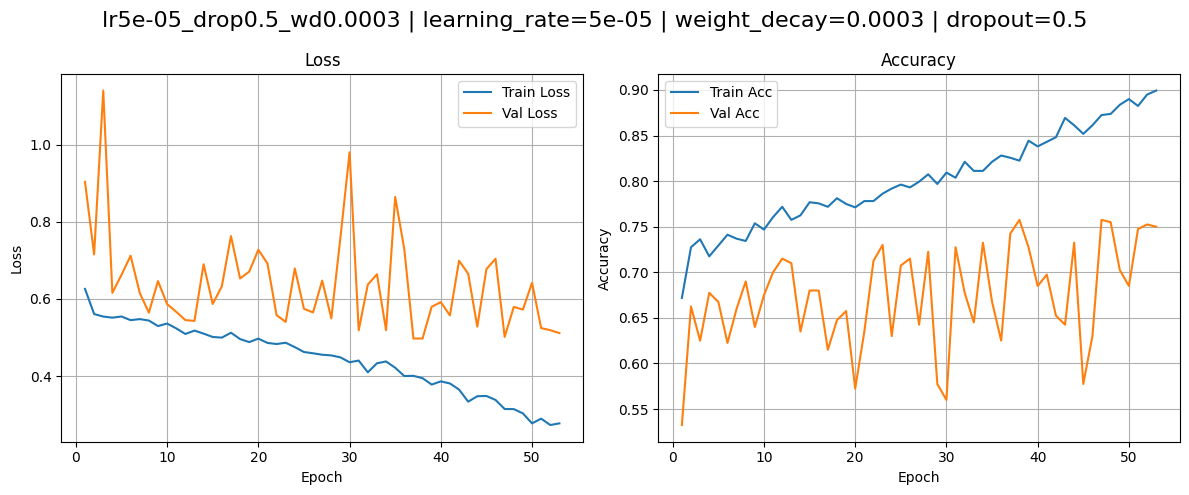

0.7575
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


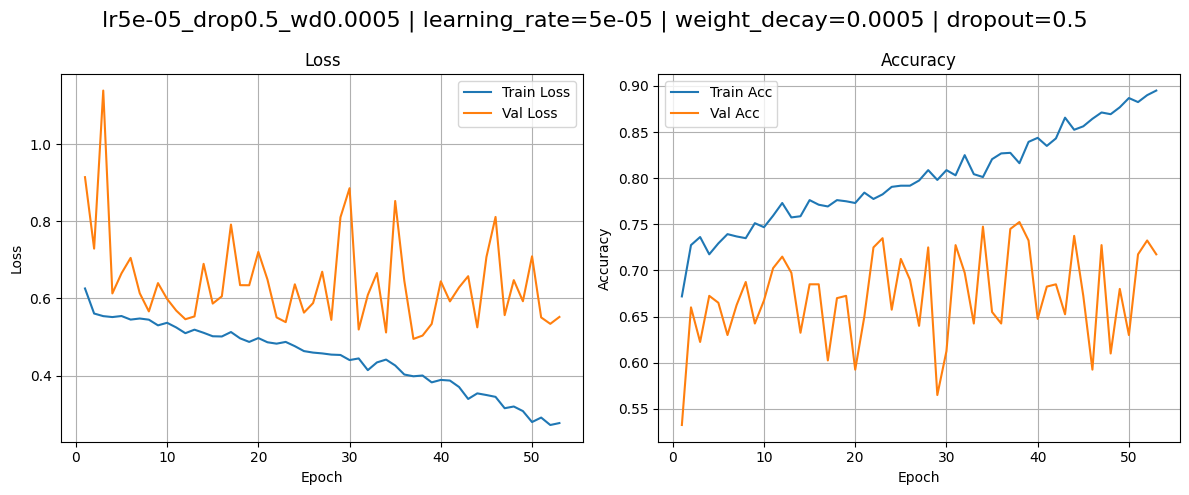

0.7525
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


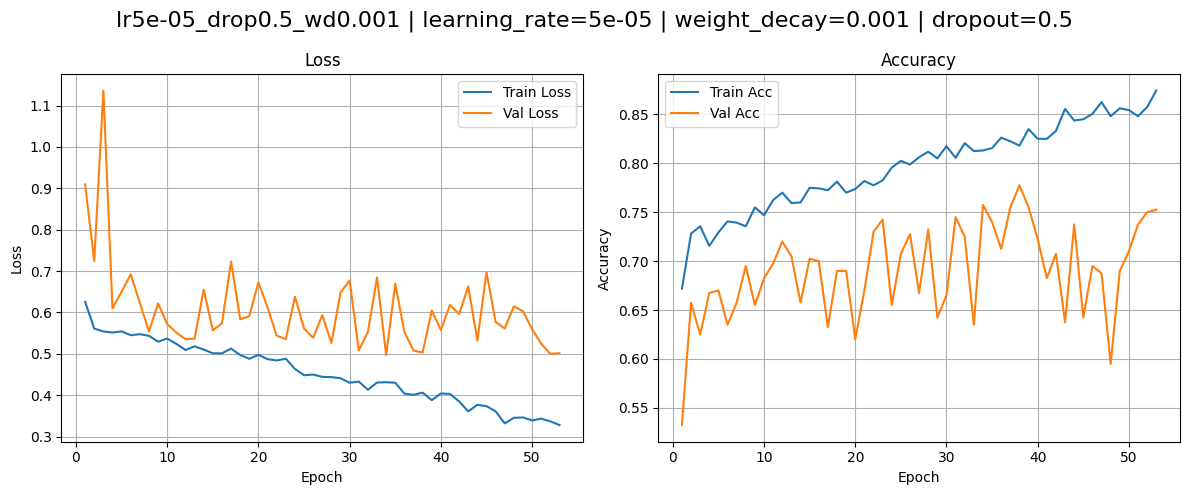

0.7775
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


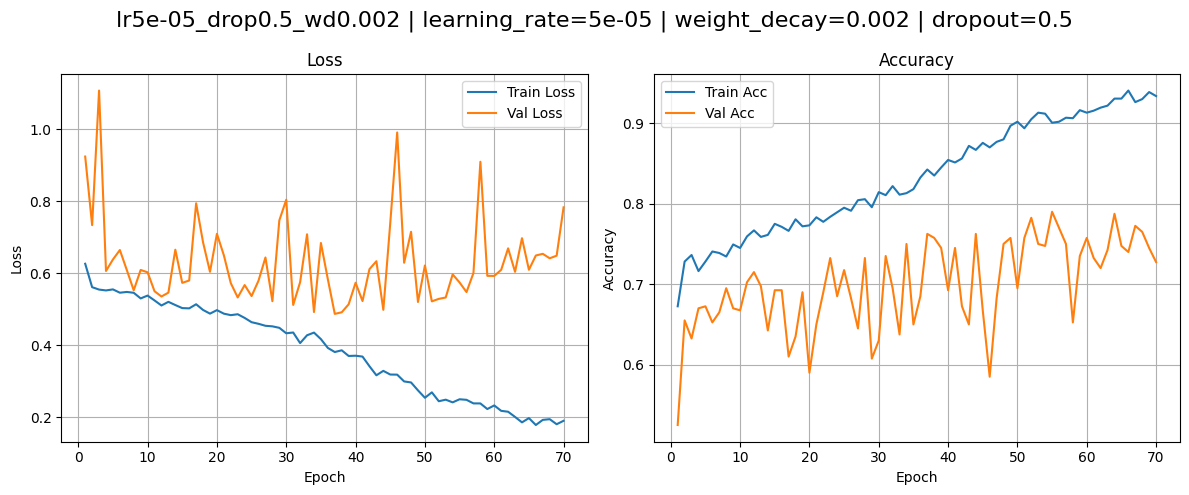

0.79
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


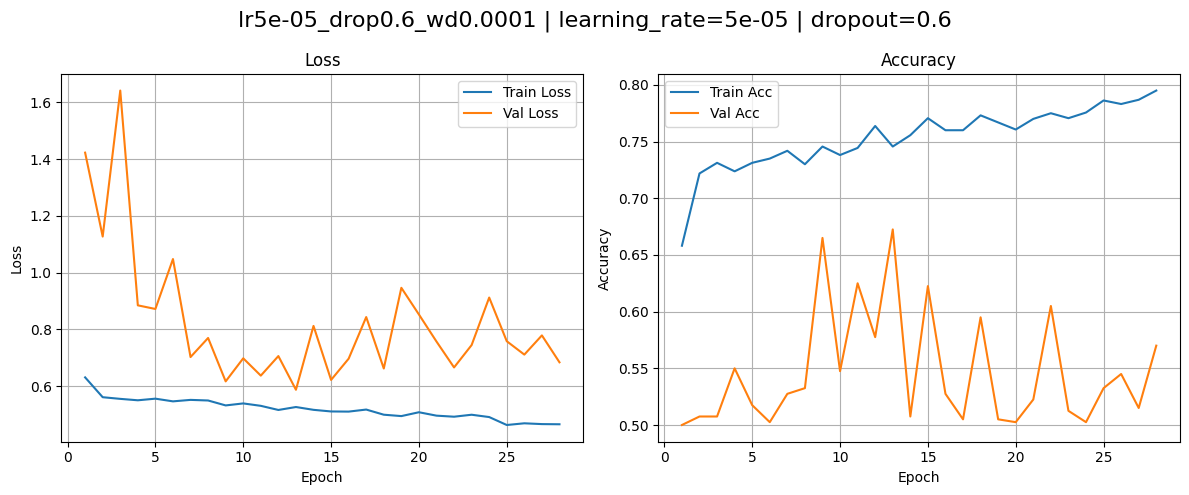

0.6725
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


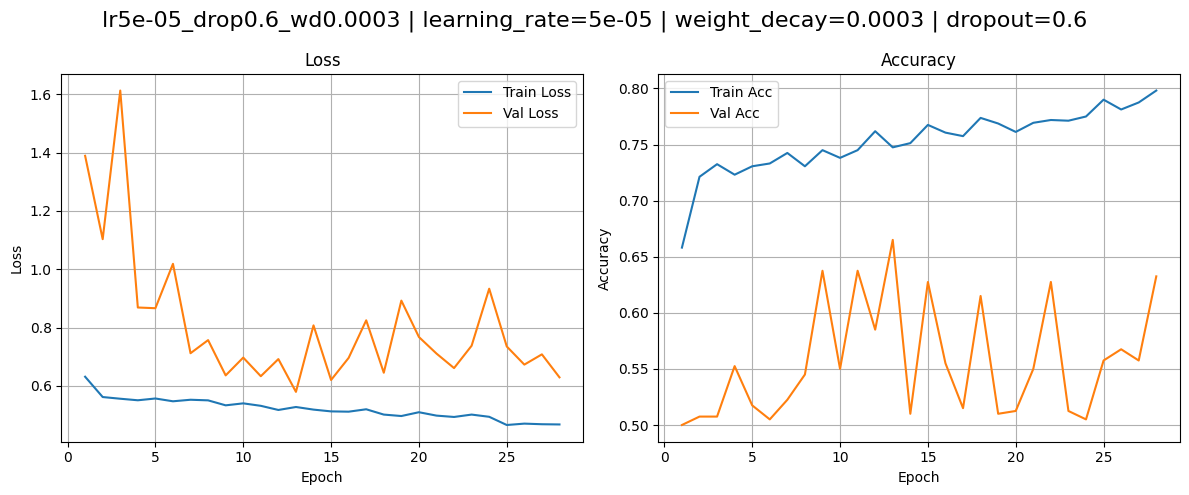

0.665
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


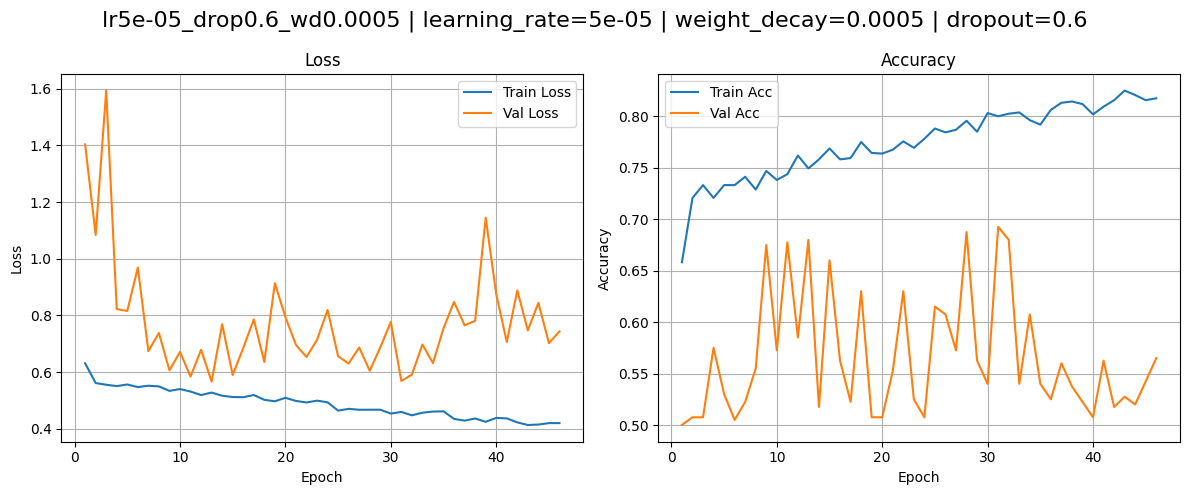

0.6925
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


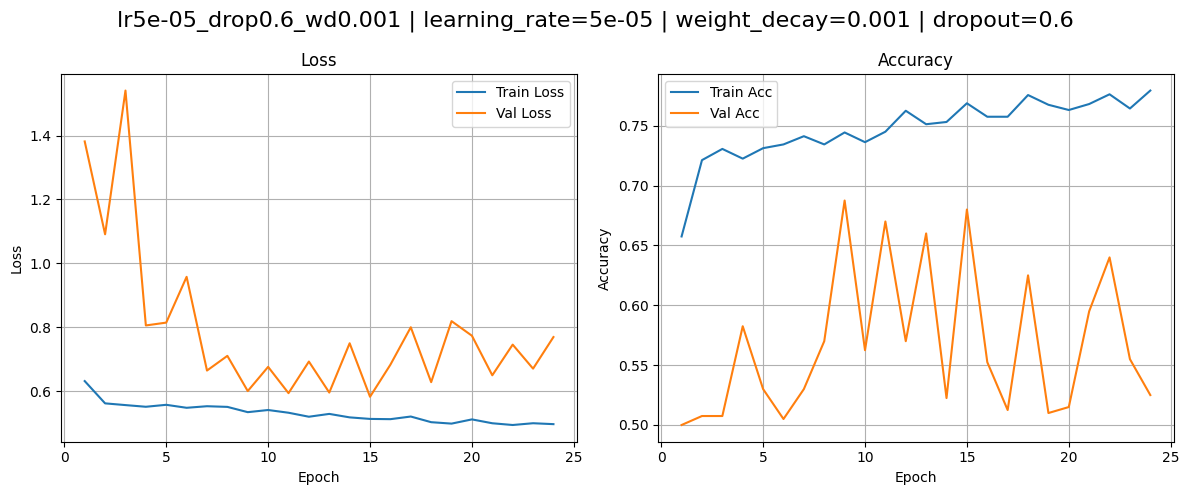

0.6875
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


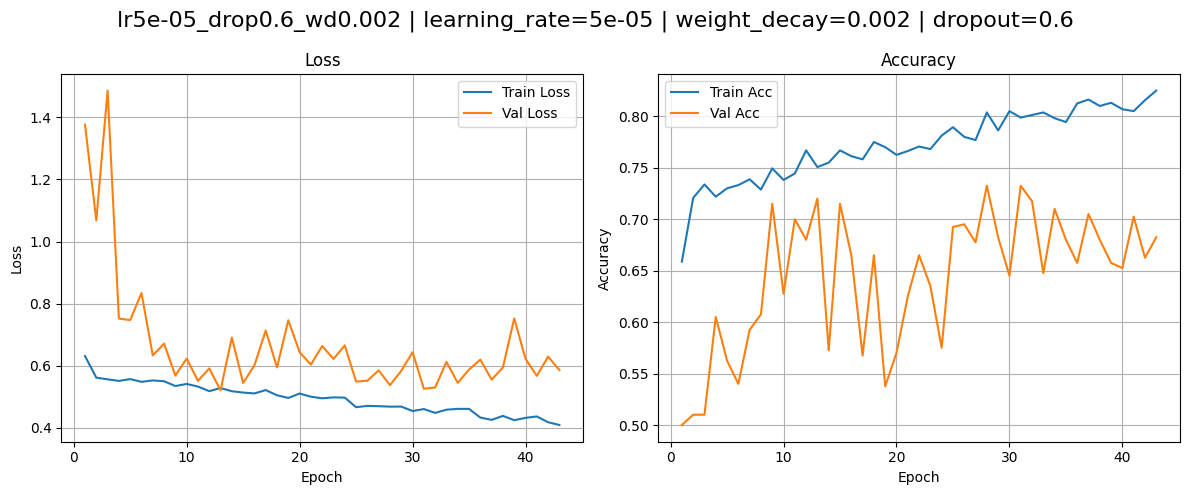

0.7325
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'batch_size': 8, 'augment': True, 'epochs': 80, 'learning_rate': 5e-05, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.002, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


In [6]:
# stgcn
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "grid_search_7_gamma_pose"
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "grid_search_7_gamma_pose_no_augment"
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "grid_search_7_combined_gamma_pose"
experiment_root = CHECKPOINT_DIR / "STGCN_V2" / "initial_search"
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "grid_search_8"



default_config = DEFAULT_STGCN_PARAMS_V1

plot_grid_search_results(experiment_root, default_config=default_config)